## Tarea 1 - Patricio Sepúlveda Ewert

## Pregunta 1 — Carga, Exploración y Limpieza

**Estructura inicial.** El dataset tiene **5.621 observaciones y 22 variables**, con 16 numéricas (`float64`), 1 entera (`student_id`) y 5 categóricas (`object`). `exercise_minutes` aparece como `object` debido a la presencia del sufijo `' min'` en 602 observaciones.

**Valores faltantes.** Todas las variables (excepto `student_id`) presentan entre un 9 % y un 13 % de datos faltantes, con la excepción crítica de `drug_use`, que tiene un **72.99 %** de ausencias. La similitud en las tasas de missingness en el resto de variables es compatible con un mecanismo **MCAR (Missing Completely At Random)**, supuesto bajo el cual la eliminación listwise produce estimadores insesgados y consistentes (solo se pierde eficiencia).

**Decisiones de limpieza:**

1. **`drug_use`** eliminada: con 73 % de faltantes, ningún método de imputación es confiable.
2. **`student_id`** eliminada: no aporta información estructural.
3. **`exercise_minutes` → `exercise_hours`**: se elimina el sufijo `' min'`, se convierte a numérico y se divide entre 60 para homogeneizar unidades con el resto de variables temporales.
4. **`academic_level`**: se corrigen espacios (`.strip()`) que generaban categorías duplicadas, quedando **3 niveles limpios**: High_School, Undergraduate, Postgraduate.
5. **`part_time_job`**: se normaliza capitalización y se codifica como binaria (1 = sí, 0 = no).
6. **`study_hours` y `screen_time_hours`**: aunque la descripción sugiere que son sumas de sus componentes, el 48.5 % y 45.1 % de las observaciones respectivamente violan esta relación. Se documenta la inconsistencia y se **retienen** ambas; los modelos determinarán empíricamente su aporte.

**Variable binaria `took_exam`** (clave para P2–P4):

| Condición | `took_exam` | n |
|---|---|---|
| `exam_score > 1.0` | 1 (rindió) | 4.473 (91.1 %) |
| `exam_score = 1.0` | 0 (no rindió) | 439 (8.9 %) |
| `exam_score = NaN` | NaN (excluido) | 709 |

Los NaN se interpretan como datos genuinamente faltantes (examen realizado pero no registrado) y se excluyen — no se imputan porque eso sesgaría directamente la variable dependiente. Existe un **desbalance de clases de ~91/9 %** que afectará la capacidad predictiva sobre la clase minoritaria.

**Eliminación listwise.** Tras eliminar observaciones con al menos un NaN en predictores, se retienen **3.996 casos completos (71.1 %)**. Bajo MCAR esto no introduce sesgo.

**Codificación categórica.** Se crean dummies con categorías de referencia explícitas: `gender` → Male, `academic_level` → High_School, `internet_quality` → Good.

**Descriptivas y diagnósticos.** Todas las variables numéricas presentan distribuciones razonables y rangos fisiológicamente plausibles. Los outliers por IQR son inferiores al 0.6 % en todas las variables, por lo que se **mantienen** para evitar sesgo de selección. La matriz de correlación y el VIF muestran que `productivity_score` presenta VIF = 11.54 (multicolinealidad moderada-alta), lo cual se documenta como limitación; los demás predictores están por debajo del umbral crítico.

---

## Pregunta 2 — Modelo de Probabilidad Lineal (MPL / MCO)

**Especificación:** $P(\text{took\_exam}_i=1) = \beta_0 + \sum_k \beta_k X_{ki} + \varepsilon_i$, estimado por MCO con errores estándar **HC3** (robustos a la heterocedasticidad estructural del MPL, donde $\text{Var}(\varepsilon_i)=p_i(1-p_i)$). Selección de variables por **eliminación hacia atrás** con umbral $p < 0.05$ partiendo de los 22 predictores.

**Modelo final (4 variables, R² = 0.2458):**

| Variable | β | Interpretación (puntos porcentuales) |
|---|---|---|
| `focus_index` | +0.0039*** | +0.39 p.p. por unidad adicional |
| `burnout_level` | –0.0025*** | –0.25 p.p. por unidad adicional |
| `productivity_score` | +0.0056*** | +0.56 p.p. por unidad adicional |
| `academic_Undergraduate` | +0.0264*** | +2.64 p.p. vs categoría High_School |

**Significados económicos:** mayor concentración, mayor productividad autorreportada y ser *Undergraduate* (respecto a *High School*) aumentan la probabilidad de rendir el examen; mayor agotamiento (burnout) la reduce. Todos los coeficientes son significativos al 1 %.

**Limitación estructural del MPL.** El **27.82 %** de las probabilidades predichas cae fuera del intervalo [0, 1], lo que confirma la necesidad de modelos no lineales acotados. Además, el MPL tiende a predecir siempre la clase mayoritaria (0 % de recall sobre "no rindió"), reflejando tanto el desbalance de clases como la rigidez del efecto marginal constante.

---

## Pregunta 3 — Modelo Probit

**Especificación:** $P(\text{took\_exam}_i=1) = \Phi(X_i'\beta)$, donde $\Phi$ es la CDF normal estándar. Estimación por Máxima Verosimilitud. Interpretación mediante **AME** (Average Marginal Effects): cambio promedio en la probabilidad evaluado en los valores observados de cada individuo.

**Modelo final (4 variables, Pseudo-R² = 0.5878):**

| Variable | AME | p.p. |
|---|---|---|
| `focus_index` | +0.0034*** | +0.34 p.p. |
| `burnout_level` | –0.0025*** | –0.25 p.p. |
| `productivity_score` | +0.0067*** | +0.67 p.p. |
| `academic_Undergraduate` | +0.0176*** | +1.76 p.p. |

La selección backward arroja exactamente el **mismo conjunto de variables** que el MPL. Los signos coinciden y la magnitud de los efectos marginales promedio es comparable. El Probit soluciona la limitación del MPL: todas las probabilidades predichas se encuentran en [0, 1].

---

## Pregunta 4 — Modelo Logit

**Especificación:** $P(\text{took\_exam}_i=1) = \frac{e^{X_i'\beta}}{1+e^{X_i'\beta}}$. Permite dos interpretaciones complementarias: **AME** (cambio en p.p.) y **Odds Ratios** ($e^{\hat\beta}$, factor multiplicativo sobre las odds).

**Modelo final (5 variables, Pseudo-R² = 0.5883):**

| Variable | AME (p.p.) | OR | Interpretación Odds |
|---|---|---|---|
| `upcoming_deadline` | +1.56 p.p. ** | 1.53 | odds aumentan 53.4 % |
| `focus_index` | +0.34 p.p. *** | 1.10 | odds aumentan 9.7 % |
| `burnout_level` | –0.27 p.p. *** | 0.93 | odds disminuyen 7.2 % |
| `productivity_score` | +0.68 p.p. *** | 1.20 | odds aumentan 20.4 % |
| `academic_Undergraduate` | +1.73 p.p. *** | 1.61 | odds aumentan 60.7 % |

El Logit recupera `upcoming_deadline` como significativa (al 5 %), que no sobrevivía en MPL ni Probit. Aporta, además, la interpretación en *odds ratios*, estándar en economía y ciencias sociales. La matriz de confusión mejora sustancialmente frente al MPL: recall de 59 % sobre la clase minoritaria vs 0 % del MPL.

---

## Pregunta 5 — Comparación MPL, Probit y Logit

**1. Diferencias estructurales.** El MPL supone efectos marginales constantes sobre toda la distribución de $X$, lo que genera predicciones fuera de [0, 1] (27.8 % de los casos) y heterocedasticidad intrínseca. Probit y Logit usan funciones de enlace $S$ que acotan la probabilidad en [0, 1] y capturan no linealidades.

**2. Probit vs Logit.** Difieren en el supuesto distribucional de los errores latentes (normal estándar vs. logística). Con $n \approx 3.975$, los AME convergen numéricamente y las diferencias son prácticamente irrelevantes en magnitud.

**3. Modelo más adecuado.** El **Logit** es la mejor opción para responder la pregunta de investigación por tres razones: (i) garantiza probabilidades en [0, 1]; (ii) sus coeficientes tienen interpretación directa como log-odds y permiten reportar OR, métrica estándar en la literatura; (iii) logró el mejor desempeño sobre la clase minoritaria (recall 59 % vs 0 % del MPL).

**4. Variables robustas a la especificación** (significativas al 5 % o más en los tres modelos):
- `focus_index` (+) — concentración
- `burnout_level` (–) — agotamiento
- `productivity_score` (+) — productividad
- `academic_Undergraduate` (+) — nivel Undergraduate vs High_School

Estas cuatro variables constituyen el **núcleo causal robusto** de la probabilidad de rendir el examen. La variable `upcoming_deadline` es significativa únicamente en Logit y podría interpretarse como marginalmente relevante.

**5. Limitación compartida.** El desbalance de clases (~91/9 %) limita estructuralmente la capacidad predictiva sobre estudiantes que no rindieron.

---

## Pregunta 6 — Modelo Poisson para la Nota del Examen

**Muestra:** 3.630 estudiantes que rindieron (`took_exam = 1`).
**Variable dependiente:** `exam_score_int` = `exam_score` redondeado al entero más cercano.
**Limitación documentada:** `exam_score` es una variable continua, no un conteo natural. El redondeo es la transformación mínima para cumplir con el requisito formal del Poisson (soporte en enteros no negativos).

**Estadística descriptiva clave:** Media = 20.52, Varianza = 127.65 → **ratio Var/Media = 6.22**. Esta primera señal indica que el supuesto Poisson (equidispersión, Var = Media) es violado severamente.

**Modelo final (5 variables):**

| Variable | β | IRR | EM (pts) | Interpretación |
|---|---|---|---|---|
| `upcoming_deadline` | –0.0266*** | 0.974 | –0.55 | –2.63 % en nota esperada |
| `mental_health_score` | +0.0070*** | 1.007 | +0.14 | +0.71 % |
| `focus_index` | +0.0135*** | 1.014 | +0.28 | +1.36 % |
| `burnout_level` | –0.0088*** | 0.991 | –0.18 | –0.87 % |
| `productivity_score` | +0.0211*** | 1.021 | +0.43 | +2.14 % |

**Advertencia explícita:** la devianza/gl = 1.75 y el ratio Var/Media = 6.22 sugieren sobredispersión. Por tanto los **errores estándar están subestimados** y los p-values son artificialmente pequeños. Esto motiva los análisis de las Preguntas 7 y 8.

---

## Pregunta 7 — Diagnóstico de Sobredispersión y α Óptimo

Se aplican **tres pruebas convergentes**:

1. **Descriptivo:** Var/Media = 6.22 (si Poisson fuera correcto, debería ser ≈ 1).
2. **Test de Cameron–Trivedi (1990):** regresión auxiliar $(y-\hat\mu)^2 - y = \alpha \hat\mu^2 + u$. Resultado: $\hat\alpha = 0.0299$, $t = 28.13$, $p < 10^{-8}$ → **rechaza H₀ (equidispersión)**.
3. **Estimación directa por NB2:** $\hat\alpha = 0.0284$, IC 95 %: [0.0242, 0.0325], significativo al 1 %.

**Conclusión:** los tres métodos convergen. La sobredispersión es estadísticamente significativa y cuantitativamente relevante. El **valor óptimo de α es aproximadamente 0.0284**, que implica una estructura de varianza $\text{Var}(Y) = \mu + 0.0284 \cdot \mu^2$. El modelo Poisson no es apropiado; la Binomial Negativa es necesaria.

---

## Pregunta 8 — Modelo Binomial Negativa (NB2)

**Especificación:** $E[Y_i|X_i] = \mu_i$, $\text{Var}[Y_i] = \mu_i + \alpha \mu_i^2$, con $\alpha > 0$ capturando heterogeneidad no observada entre estudiantes.

**Nota técnica:** al estimar con los 22 predictores, la Hessiana resulta casi singular (p-values NaN), señal de sobreparametrización. Se recurre al conjunto de variables seleccionadas por Poisson, que converge sin problemas.

**Modelo final (5 variables, α = 0.0284):**

| Variable | β | IRR | EM (pts) | Interpretación |
|---|---|---|---|---|
| `upcoming_deadline` | –0.0293*** | 0.971 | –0.61 | –2.89 % en nota esperada |
| `mental_health_score` | +0.0057*** | 1.006 | +0.12 | +0.57 % |
| `focus_index` | +0.0146*** | 1.015 | +0.30 | +1.47 % |
| `burnout_level` | –0.0094*** | 0.991 | –0.19 | –0.94 % |
| `productivity_score` | +0.0224*** | 1.023 | +0.46 | +2.26 % |

Todas las variables permanecen significativas al 1 %. La interpretación económica es idéntica al Poisson: concentración, salud mental y productividad elevan la nota esperada; próxima entrega y agotamiento la reducen.

---

## Pregunta 9 — Comparación Poisson vs Binomial Negativa

**1. Coeficientes similares, errores estándar distintos.** La sobredispersión **no sesga** los coeficientes del Poisson (pseudo-ML sigue siendo consistente), pero **subestima** los errores estándar en un factor aproximado de $\sqrt{1+\alpha\bar\mu}$. Esto infla los t-estadísticos y produce p-values artificialmente pequeños.

**2. Test de Razón de Verosimilitud (LRT).** $H_0: \alpha = 0$ vs $H_1: \alpha > 0$ (test de frontera, p-value dividido por 2). Resultado: LRT = **361.82**, $p < 10^{-8}$ → **rechaza Poisson con contundencia**.

**3. Indicadores de ajuste.**

| Modelo | Log-Lik | AIC | BIC | α |
|---|---|---|---|---|
| Poisson (final) | –11.632.41 | 23.276.82 | 23.314.00 | — |
| Binomial Negativa (final) | –11.451.50 | 22.917.00 | 22.960.38 | 0.0284 |

La NB gana en los tres criterios (Log-Lik más alto, AIC y BIC menores).

**4. Origen de la sobredispersión.** Heterogeneidad no observada entre estudiantes (motivación, contexto familiar, estado de salud el día del examen, etc.) que genera varianza adicional no capturada por los regresores.

**5. Modelo más adecuado.** La **Binomial Negativa** es el modelo correcto para esta pregunta de investigación: (a) el ratio Var/Media ≫ 1, (b) Cameron–Trivedi rechaza $H_0$ con $p \approx 0$, (c) LRT rechaza Poisson con $p \approx 0$, y (d) presenta menores AIC y BIC. Sus errores estándar son los válidos.

**6. Variables robustas al supuesto distribucional** (significativas al 1 % en ambos modelos):
- `focus_index` (+)
- `burnout_level` (–)
- `mental_health_score` (+)
- `productivity_score` (+)
- `upcoming_deadline` (–)

Estas cinco variables tienen efectos **genuinos y robustos** sobre la nota esperada, independientes del supuesto de dispersión. Constituyen el conjunto explicativo más confiable para el desempeño académico en esta muestra.

---

## Síntesis Global

A través de los dos bloques de modelos (binarios para asistencia y de conteo para nota), emergen consistentemente **tres variables centrales** que operan sobre el desempeño académico:

- **`productivity_score`** y **`focus_index`**: efecto positivo y robusto tanto sobre rendir el examen como sobre la nota obtenida.
- **`burnout_level`**: efecto negativo robusto en ambos bloques.

Estos hallazgos son coherentes con la literatura sobre rendimiento académico: la productividad, la concentración y la ausencia de agotamiento constituyen los determinantes proximales más consistentes, por encima de factores demográficos, de estilo de vida o socioeconómicos observables en este dataset.


## Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

---
## Pregunta 1 - Carga, Exploración y Limpieza de Datos

### 1.A  Carga y Exploración Inicial

In [2]:
df = pd.read_csv("../../data/student_productivity.csv")
n_orig     = len(df)
n_vars_orig= df.shape[1]
print(f'Dimensiones originales: {df.shape[0]} × {df.shape[1]}')
df.head()

Dimensiones originales: 5621 × 22


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0000,NaN,Undergraduate,5.3700,2.0900,1.8500,3.6600,2.3200,7.7300,5.6800,54.0,475.0000,No,0.0000,Good,3.0000,NaN,19.0100,31.7700,42.5900,25.0800
1,2,16.0000,Female,High School,5.8500,5.0400,1.8700,3.6000,2.7900,6.1100,8.9600,63.0,362.0000,no,0.0000,Good,10.0000,NaN,42.1000,45.8900,67.1500,37.8300
2,3,18.0000,Female,Undergraduate,5.6900,2.2700,0.0000,2.9300,3.9400,7.1100,11.0200,28.0,200.0000,No,0.0000,Average,5.0000,NaN,21.9300,37.0700,37.6800,18.6600
3,4,24.0000,Male,Undergraduate,2.3200,1.0600,2.3000,4.3400,2.3700,8.5400,8.7300,55.0,233.0000,No,1.0000,Poor,3.0000,1.0000,13.4700,43.6300,12.8300,1.0000
4,5,24.0000,Female,Postgraduate,3.8700,2.6300,2.5400,3.7100,1.3000,7.6900,9.6000,60.0,159.0000,No,1.0000,Poor,2.0000,NaN,19.9500,56.6200,18.5300,7.7800


In [3]:
print('Tipos de Datos:')
print(df.dtypes)
print()
df.info()

Tipos de Datos:
student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
m_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
m_df = m_df[m_df['Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)
print('Valores Faltantes por Variable:')
print(m_df.to_string())

Valores Faltantes por Variable:
                      Faltantes  Porcentaje (%)
drug_use                   4103         72.9900
upcoming_deadline           717         12.7600
burnout_level               716         12.7400
exam_score                  709         12.6100
part_time_job               703         12.5100
online_classes_hours        682         12.1300
mental_health_score         675         12.0100
self_study_hours            667         11.8700
gaming_hours                656         11.6700
social_media_hours          656         11.6700
age                         648         11.5300
productivity_score          638         11.3500
focus_index                 633         11.2600
academic_level              630         11.2100
caffeine_intake_mg          600         10.6700
exercise_minutes            599         10.6600
screen_time_hours           586         10.4300
study_hours                 574         10.2100
gender                      558          9.9300
sleep_ho

### 1.B  Limpieza y Estandarización de Datos

#### Eliminación de `drug_use`

Se elimina `drug_use` porque el **72.99 %** de sus valores son ausentes (4.103 de 5.621 observaciones). Con más de dos tercios de los datos faltantes, ningún método de tratamiento es válido.

In [5]:
df = df.drop(columns=['drug_use'])

#### Eliminación de `student_id`

Ya que el identificador único no posee contenido informativo para los modelos econométricos.

In [6]:
df = df.drop(columns=['student_id'])

#### Limpieza y conversión de `exercise_minutes` → `exercise_hours`

**Problema detectado:** 602 observaciones contienen el sufijo `' min'` (ej. `'28.0 min'`), lo que fuerza el tipo *string* e impide operaciones numéricas.

Por ello, se elimina el sufijo, se convierte a numérico y se divide entre 60 para obtener `exercise_hours`. La conversión a horas es necesaria para **homogeneizar las unidades** de todas las variables de tiempo (el resto está en horas), facilitando la interpretación y comparación directa de coeficientes en los modelos. El rango resultante [0 – 2.48 h/día] es fisiológicamente plausible.

In [7]:
df['exercise_minutes'] = (
    df['exercise_minutes'].astype(str)
    .str.replace(' min', '', regex=False).str.strip()
)
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')
df['exercise_hours']   = df['exercise_minutes'] / 60
df = df.drop(columns=['exercise_minutes'])
print('exercise_hours creada.')
print(df['exercise_hours'].describe())

exercise_hours creada.
count   5022.0000
mean       1.2444
std        0.7162
min        0.0000
25%        0.6167
50%        1.2500
75%        1.8667
max        2.4833
Name: exercise_hours, dtype: float64


#### Estandarización de `academic_level`

**Problema detectado:** Espacios en blanco al final del string generan 7 categorías aparentes en lugar de 3 (`'High School'` vs `'High School '`). Una codificación dummy sin corregir esto generaría columnas redundantes e incorrectas.

Por tal motivo, se aplica `.str.strip()` y se reemplaza el espacio interno por `_`.

In [8]:
df['academic_level'] = df['academic_level'].str.strip().str.replace(' ', '_')
print(df['academic_level'].value_counts(dropna=False))

academic_level
Postgraduate     1695
High_School      1668
Undergraduate    1628
NaN               630
Name: count, dtype: int64


#### Estandarización y binarización de `part_time_job`

**Problema detectado:** Capitalización inconsistente genera 4 valores distintos (`'Yes'`/`'yes'`, `'No'`/`'no'`).

Debido a lo anterior, se normaliza a minúsculas y se codifica como binario entero (1 = tiene trabajo part-time, 0 = no tiene).

In [9]:
df['part_time_job'] = df['part_time_job'].str.lower().map({'yes': 1, 'no': 0})
print(df['part_time_job'].value_counts(dropna=False))

part_time_job
0.0000    2469
1.0000    2449
NaN        703
Name: count, dtype: int64


#### `study_hours` y `screen_time_hours` — Documentación de inconsistencia y retención

Aunque la descripción define `study_hours` como total de `self_study_hours` + `online_classes_hours`, y `screen_time_hours` como total de tiempo frente a pantallas, el análisis empírico muestra inconsistencia interna: en el **48.5 %** de los casos `study_hours < self_study + online_classes`, y en el **45.1 %**, `screen_time < gaming + social + online`. Esto indica que los encuestados reportaron cada variable de forma independiente.

**Decisión:** Se **retienen** ambas variables. Podrían capturar información adicional no recogida por sus componentes (ej. clases presenciales en `study_hours`). Se documenta la inconsistencia como limitación y se deja que los modelos determinen empíricamente si aportan poder explicativo adicional.

In [10]:
df_chk  = df[['self_study_hours','online_classes_hours','study_hours']].dropna()
diff1   = df_chk['study_hours'] - df_chk['self_study_hours'] - df_chk['online_classes_hours']
n1_men  = (diff1 < -0.01).sum()
print('study_hours vs self_study + online_classes')
print(f'  Casos con study < self+online: {n1_men} ({100*n1_men/len(df_chk):.1f}%)  → RETENIDA\n')

df_chk2 = df[['screen_time_hours','gaming_hours','social_media_hours','online_classes_hours']].dropna()
diff2   = (df_chk2['screen_time_hours']-df_chk2['gaming_hours']
           -df_chk2['social_media_hours']-df_chk2['online_classes_hours'])
n2_men  = (diff2 < -0.01).sum()
print('screen_time_hours vs gaming + social + online')
print(f'  Casos con screen < suma: {n2_men} ({100*n2_men/len(df_chk2):.1f}%)  → RETENIDA')

study_hours vs self_study + online_classes
  Casos con study < self+online: 2250 (48.5%)  → RETENIDA

screen_time_hours vs gaming + social + online
  Casos con screen < suma: 2054 (45.1%)  → RETENIDA


#### Creación de la variable binaria `took_exam`

Según la descripción, `exam_score = 1.0` identifica a los estudiantes que **no rindieron** el examen. Se asume que este es un valor centinela artificial y no una nota real, basándose en que: (a) la escala de notas llega hasta 64 puntos, por lo que una nota de exactamente 1.0 sería extremadamente inusual como resultado, y (b) la descripción lo define explícitamente como indicador de no-rendición.

**Supuesto sobre los NaN en `exam_score` (709 obs.):** Se interpretan como **datos genuinamente faltantes** (el examen existió pero la nota no fue registrada), y se excluyen de los modelos 2–4. No se imputan porque `took_exam` es la variable dependiente: asignar 0 o 1 artificialmente sesgaría directamente los coeficientes estimados.

| Condición | `took_exam` | n |
|---|---|---|
| `exam_score > 1.0` | 1 (rindió) | 4.473 |
| `exam_score = 1.0` | 0 (no rindió) | 439 |
| `exam_score = NaN` | NaN (excluido) | 709 |

In [11]:
df['took_exam'] = np.where(df['exam_score']>1.0,1,
                  np.where(df['exam_score']==1.0,0,np.nan))
print('Distribución de took_exam:')
n1_all  = (df['took_exam']==1).sum()
n0_all  = (df['took_exam']==0).sum()
nna_all = df['took_exam'].isna().sum()
nobs_all= n1_all + n0_all
print(f'  Rindió (1):        {n1_all} ({n1_all/nobs_all*100:.1f}%)')
print(f'  No rindió (0):     {n0_all} ({n0_all/nobs_all*100:.1f}%)')
print(f'  Desconocido (NaN): {nna_all} (excluidos de P2-4, independiente del listwise)')
print(f'\n  Tasa asistencia (sobre observados): {n1_all/nobs_all*100:.2f}%')
print(f'  Clase minoritaria (no rindió):       {n0_all/nobs_all*100:.2f}%')
print('\n  Notese que existe desbalance de clases (~91% vs ~9%).')
print('  Esto puede afectar la precisión de los modelos sobre la clase minoritaria.')

Distribución de took_exam:
  Rindió (1):        4473 (91.1%)
  No rindió (0):     439 (8.9%)
  Desconocido (NaN): 709 (excluidos de P2-4, independiente del listwise)

  Tasa asistencia (sobre observados): 91.06%
  Clase minoritaria (no rindió):       8.94%

  Notese que existe desbalance de clases (~91% vs ~9%).
  Esto puede afectar la precisión de los modelos sobre la clase minoritaria.


### 1.C  Tratamiento de Valores Faltantes: Eliminación Listwise (*Complete Case Analysis*)

**Mecanismo de datos faltantes:** Se ha establecido que el mecanismo de ausencia es **MCAR (Missing Completely At Random)**: la probabilidad de que un valor falte no depende ni del propio valor faltante ni de ninguna otra variable del dataset. Bajo MCAR, la eliminación listwise produce **estimadores insesgados y consistentes** — los casos completos son una muestra aleatoria del dataset original. El único costo es una pérdida de eficiencia (mayor varianza en los estimadores por tener menos observaciones), pero no existe sesgo sistemático.

**Procedimiento:** Se eliminan todas las observaciones que tengan al menos un valor faltante en cualquiera de los predictores. Las variables dependientes (`exam_score`, `took_exam`) conservan sus NaN originales, que se manejan separadamente en cada modelo.

In [12]:
feature_cols = [
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours',
    'social_media_hours', 'gaming_hours', 'screen_time_hours',
    'sleep_hours', 'exercise_hours', 'caffeine_intake_mg',
    'part_time_job', 'upcoming_deadline', 'mental_health_score',
    'focus_index', 'burnout_level', 'productivity_score',
    'gender', 'academic_level', 'internet_quality'
]

# Identificar observaciones con NaN en predictores
has_nan_pred = df[feature_cols].isnull().any(axis=1)
n_nan_obs    = has_nan_pred.sum()
pct_nan_obs  = 100 * has_nan_pred.mean()
n_completas  = (~has_nan_pred).sum()
pct_completas= 100 * (~has_nan_pred).mean()

print('Impacto de la Eliminación Listwise')
print(f'  Dataset post-limpieza básica:           {len(df):>5} observaciones')
print(f'  Obs con al menos 1 NaN en predictores:  {n_nan_obs:>5} ({pct_nan_obs:.1f}%)')
print(f'  Obs completas retenidas:                {n_completas:>5} ({pct_completas:.1f}%)')
print(f'  Pérdida de observaciones:               {n_nan_obs:>5} ({pct_nan_obs:.1f}%)')
print()
print('  NaN por variable (motivo de eliminación):')
nan_per_var = df[feature_cols].isnull().sum().sort_values(ascending=False)
for col, n in nan_per_var[nan_per_var>0].items():
    print(f'    {col:<25}: {n:>4} NaN ({100*n/len(df):.1f}%)')

Impacto de la Eliminación Listwise
  Dataset post-limpieza básica:            5621 observaciones
  Obs con al menos 1 NaN en predictores:   1625 (28.9%)
  Obs completas retenidas:                 3996 (71.1%)
  Pérdida de observaciones:                1625 (28.9%)

  NaN por variable (motivo de eliminación):
    upcoming_deadline        :  717 NaN (12.8%)
    burnout_level            :  716 NaN (12.7%)
    part_time_job            :  703 NaN (12.5%)
    online_classes_hours     :  682 NaN (12.1%)
    mental_health_score      :  675 NaN (12.0%)
    self_study_hours         :  667 NaN (11.9%)
    gaming_hours             :  656 NaN (11.7%)
    social_media_hours       :  656 NaN (11.7%)
    age                      :  648 NaN (11.5%)
    productivity_score       :  638 NaN (11.4%)
    focus_index              :  633 NaN (11.3%)
    academic_level           :  630 NaN (11.2%)
    caffeine_intake_mg       :  600 NaN (10.7%)
    exercise_hours           :  599 NaN (10.7%)
    screen_time_ho

In [13]:
# Aplicamos listwise deletion
df_clean = df[~has_nan_pred].copy()
print(f'Dataset final (casos completos): {len(df_clean)} observaciones')
print(f'Variables: {df_clean.shape[1]}')

Dataset final (casos completos): 3996 observaciones
Variables: 21


### 1.D  Codificación de Variables Categóricas

Se crean dummies omitiendo la categoría de referencia:
- `gender`: referencia = **Male**
- `academic_level`: referencia = **High_School**
- `internet_quality`: referencia = **Good**

In [14]:
gen_d  = pd.get_dummies(df_clean['gender'],          prefix='gender',  drop_first=False,dtype=int).drop(columns=['gender_Male'])
acad_d = pd.get_dummies(df_clean['academic_level'],  prefix='academic',drop_first=False,dtype=int).drop(columns=['academic_High_School'])
inet_d = pd.get_dummies(df_clean['internet_quality'], prefix='internet',drop_first=False,dtype=int).drop(columns=['internet_Good'])

df_clean = pd.concat([df_clean, gen_d, acad_d, inet_d], axis=1)
df_clean = df_clean.drop(columns=['gender','academic_level','internet_quality'])

feature_cols = [
    'age','study_hours','self_study_hours','online_classes_hours',
    'social_media_hours','gaming_hours','screen_time_hours',
    'sleep_hours','exercise_hours','caffeine_intake_mg',
    'part_time_job','upcoming_deadline','mental_health_score',
    'focus_index','burnout_level','productivity_score',
    'gender_Female','gender_Other',
    'academic_Undergraduate','academic_Postgraduate',
    'internet_Average','internet_Poor'
]
print(f'Predictores finales: {len(feature_cols)}')
print(feature_cols)

Predictores finales: 22
['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'screen_time_hours', 'sleep_hours', 'exercise_hours', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'gender_Female', 'gender_Other', 'academic_Undergraduate', 'academic_Postgraduate', 'internet_Average', 'internet_Poor']


### 1.E  Estadísticas Descriptivas (sobre casos completos)

In [15]:
numeric_cols = [
    'age','study_hours','self_study_hours','online_classes_hours',
    'social_media_hours','gaming_hours','screen_time_hours',
    'sleep_hours','exercise_hours','caffeine_intake_mg',
    'mental_health_score','focus_index','burnout_level',
    'productivity_score','exam_score'
]
print('Estadísticas Descriptivas — Variables Numéricas (n = casos completos)')
print(df_clean[numeric_cols].describe().round(3).to_string())

Estadísticas Descriptivas — Variables Numéricas (n = casos completos)
            age  study_hours  self_study_hours  online_classes_hours  social_media_hours  gaming_hours  screen_time_hours  sleep_hours  exercise_hours  caffeine_intake_mg  mental_health_score  focus_index  burnout_level  productivity_score  exam_score
count 3996.0000    3996.0000         3996.0000             3996.0000           3996.0000     3996.0000          3996.0000    3996.0000       3996.0000           3996.0000            3996.0000    3996.0000      3996.0000           3996.0000   3975.0000
mean    20.5260       4.5390            2.4720                2.0190              2.9920        1.5670             6.9950       7.0190          1.2400            252.3340               5.5200      29.4970        45.6700             37.3600     18.8270
std      2.8630       1.8220            1.1740                0.9890              1.4790        1.1120             2.4840       1.1680          0.7180            144.6030    

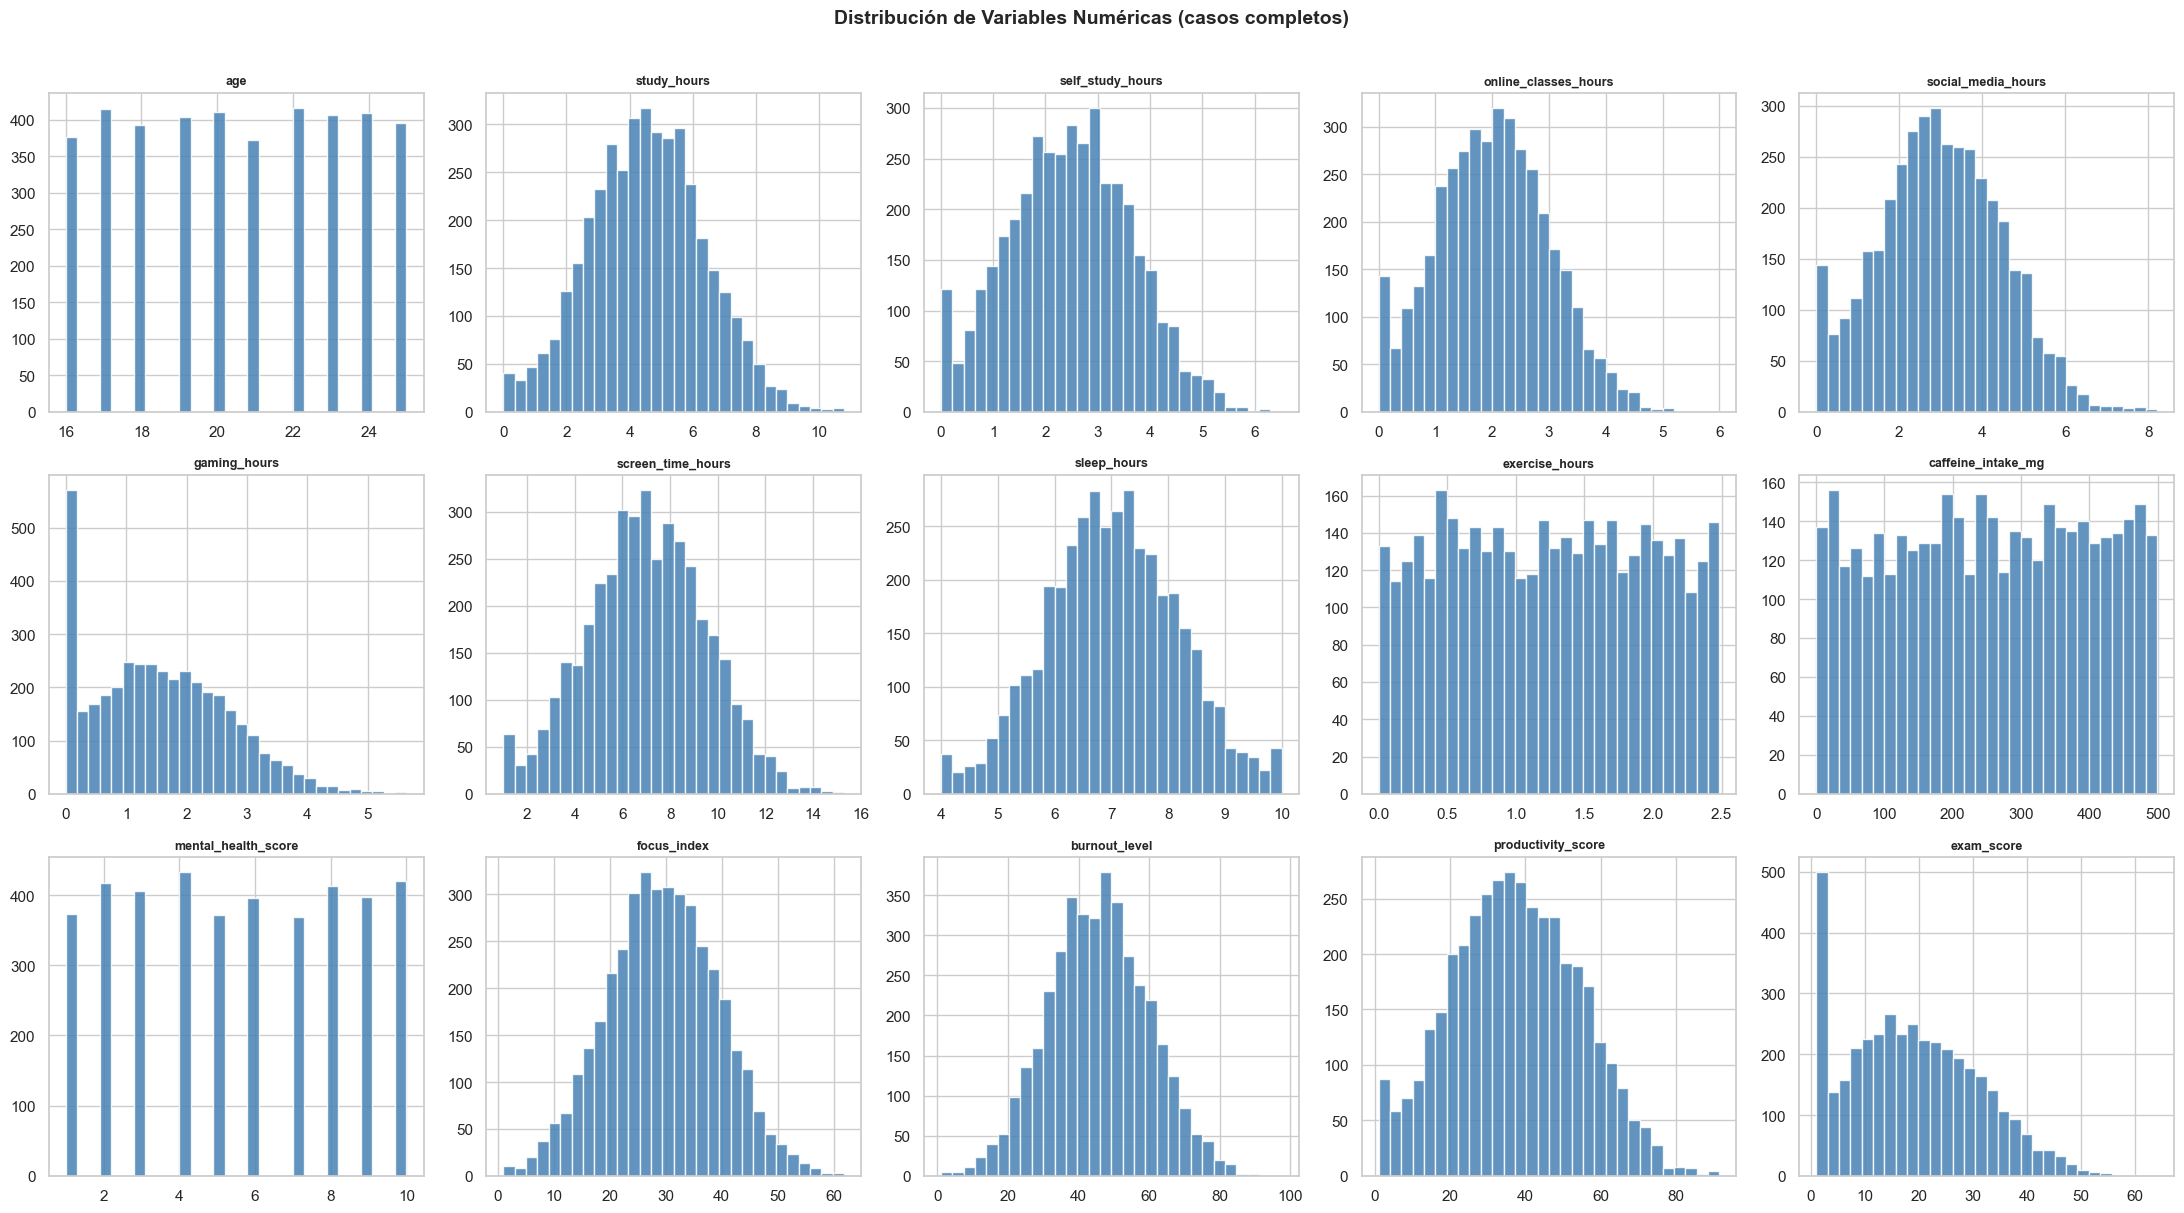

In [16]:
n_nc   = len(numeric_cols)
n_rows = (n_nc + 4) // 5
fig, axes = plt.subplots(n_rows, 5, figsize=(22, n_rows*4))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df_clean[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
for j in range(n_nc, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribución de Variables Numéricas (casos completos)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

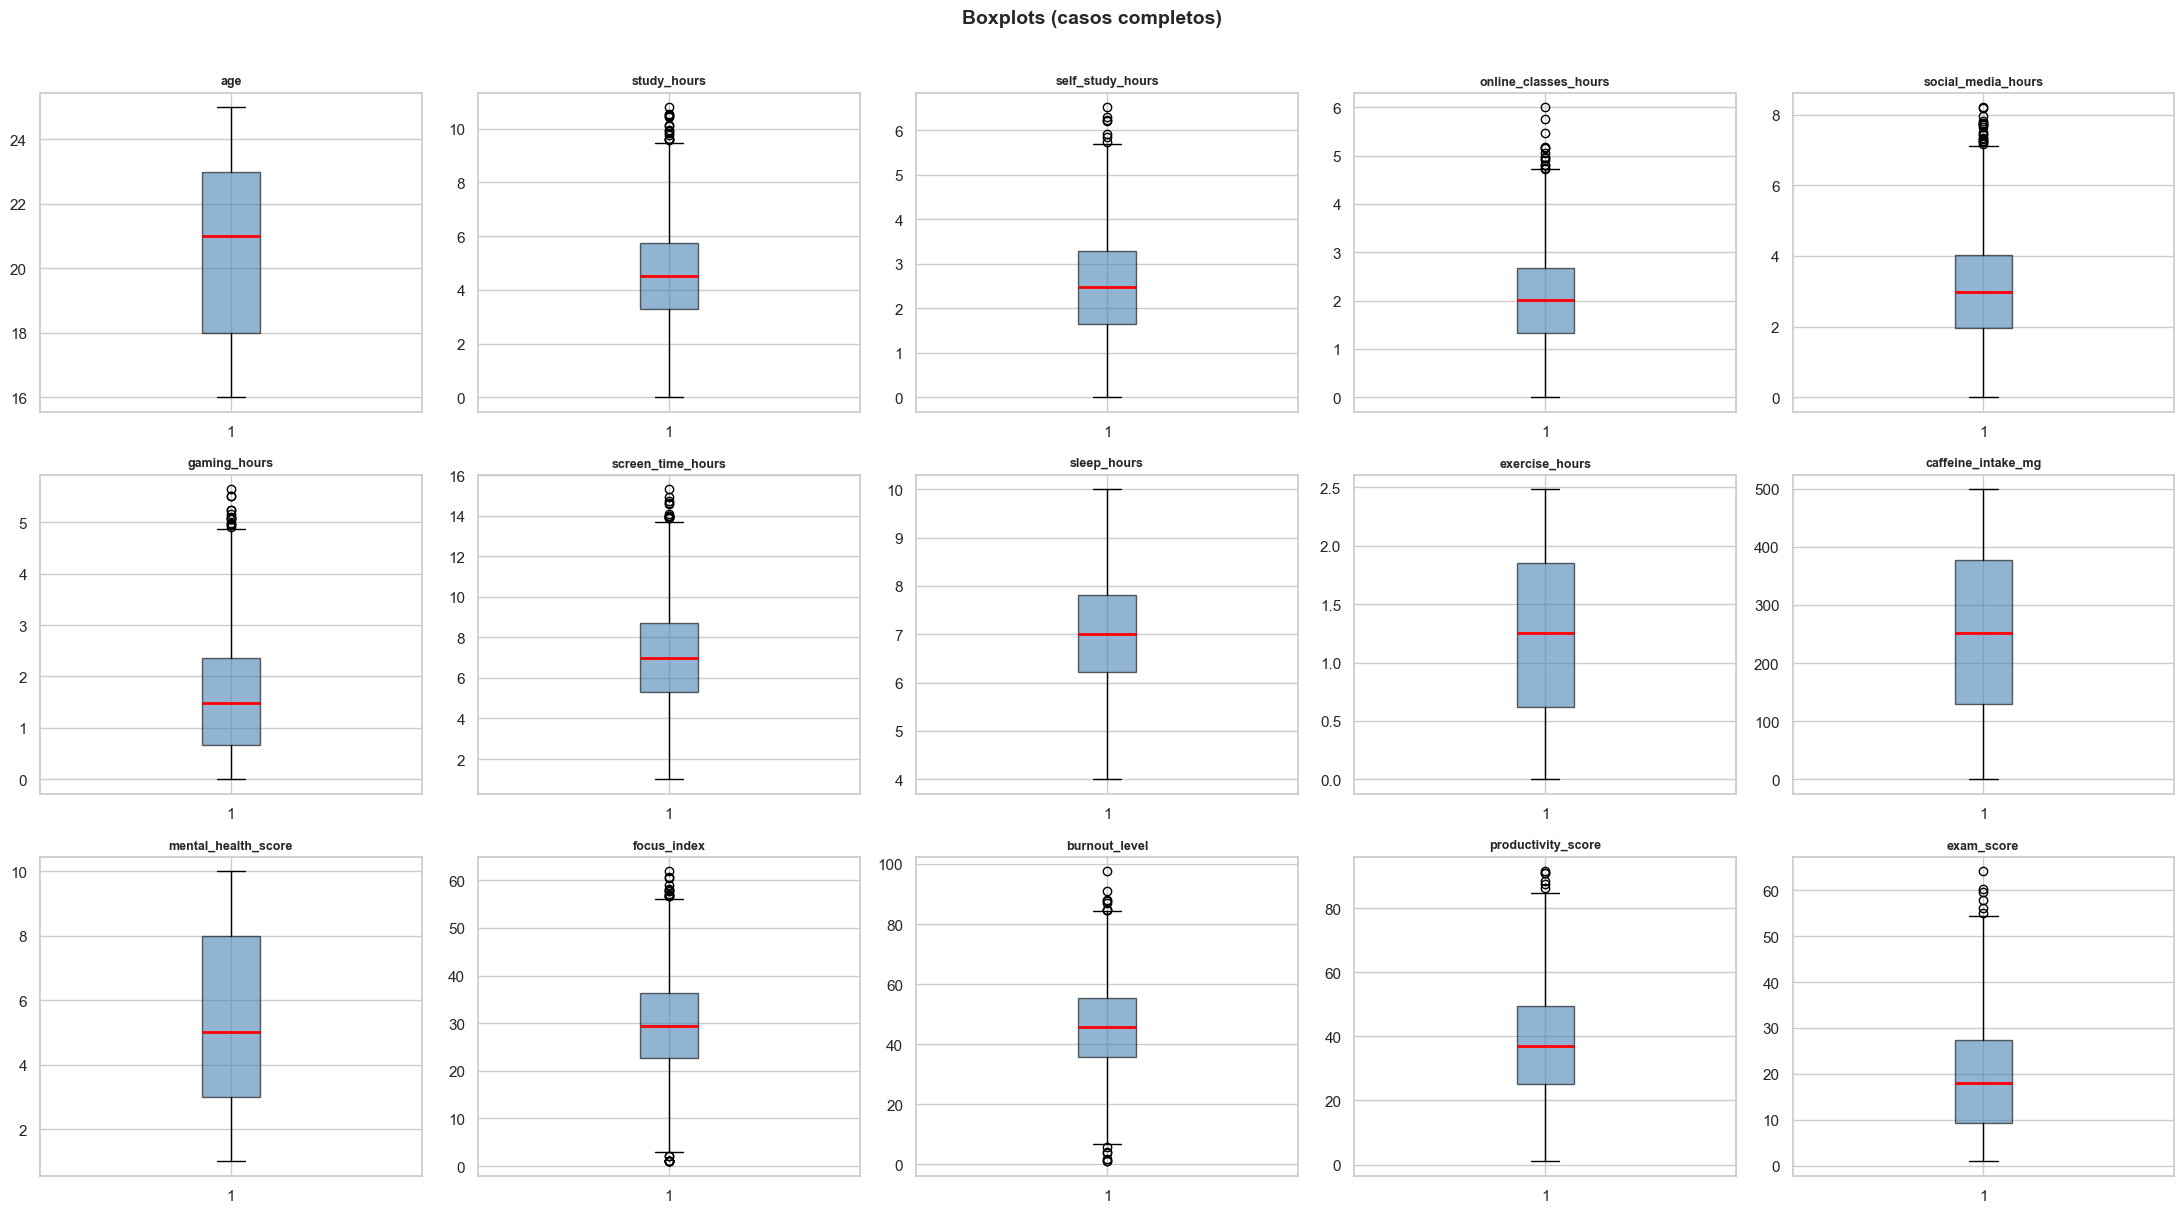

Outliers (IQR)
  age                      :    0 (0.0%)
  study_hours              :   15 (0.4%)
  self_study_hours         :    7 (0.2%)
  online_classes_hours     :   14 (0.4%)
  social_media_hours       :   18 (0.5%)
  gaming_hours             :   14 (0.4%)
  screen_time_hours        :   13 (0.3%)
  sleep_hours              :    0 (0.0%)
  exercise_hours           :    0 (0.0%)
  caffeine_intake_mg       :    0 (0.0%)
  mental_health_score      :    0 (0.0%)
  focus_index              :   22 (0.6%)
  burnout_level            :   14 (0.4%)
  productivity_score       :    6 (0.2%)
  exam_score               :    6 (0.2%)


In [17]:
fig, axes = plt.subplots(n_rows, 5, figsize=(22, n_rows*4))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='steelblue',alpha=0.6),
                   medianprops=dict(color='red',linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
for j in range(n_nc, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplots (casos completos)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print('Outliers (IQR)')
for col in numeric_cols:
    d = df_clean[col].dropna()
    Q1,Q3 = d.quantile(0.25), d.quantile(0.75)
    IQR   = Q3 - Q1
    n_out = ((d<Q1-1.5*IQR)|(d>Q3+1.5*IQR)).sum()
    print(f'  {col:<25}: {n_out:>4} ({100*n_out/len(d):.1f}%)')

Dado que el porcentaje de outliers es inferior al 0.6 % en todas las variables y los valores extremos son plausibles, se **decide mantenerlos** para evitar sesgo de selección

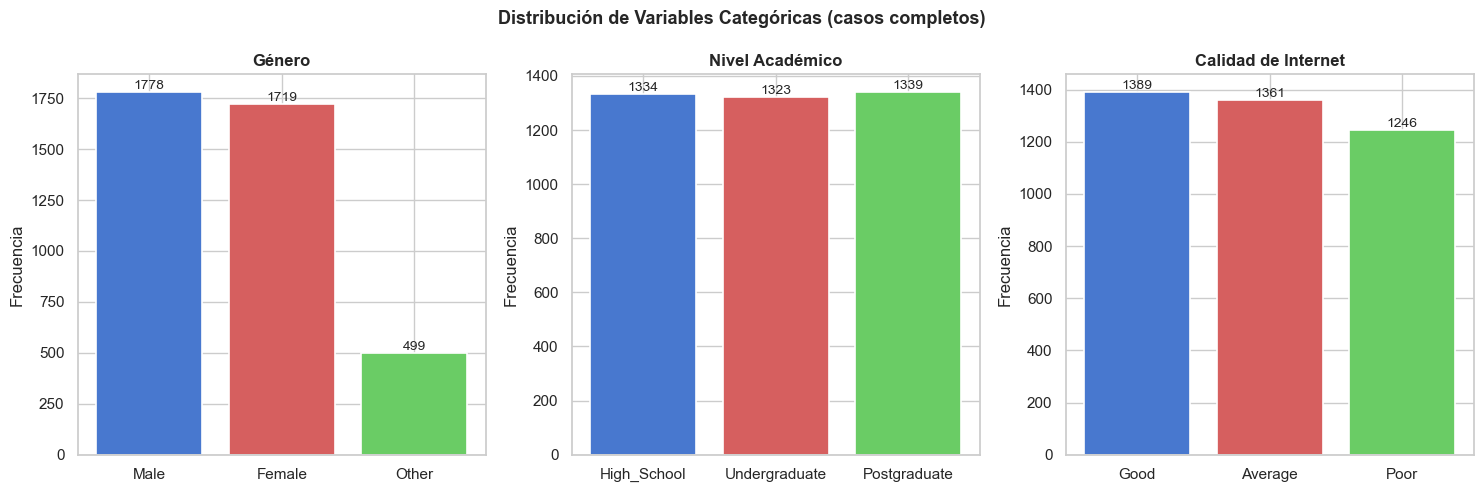

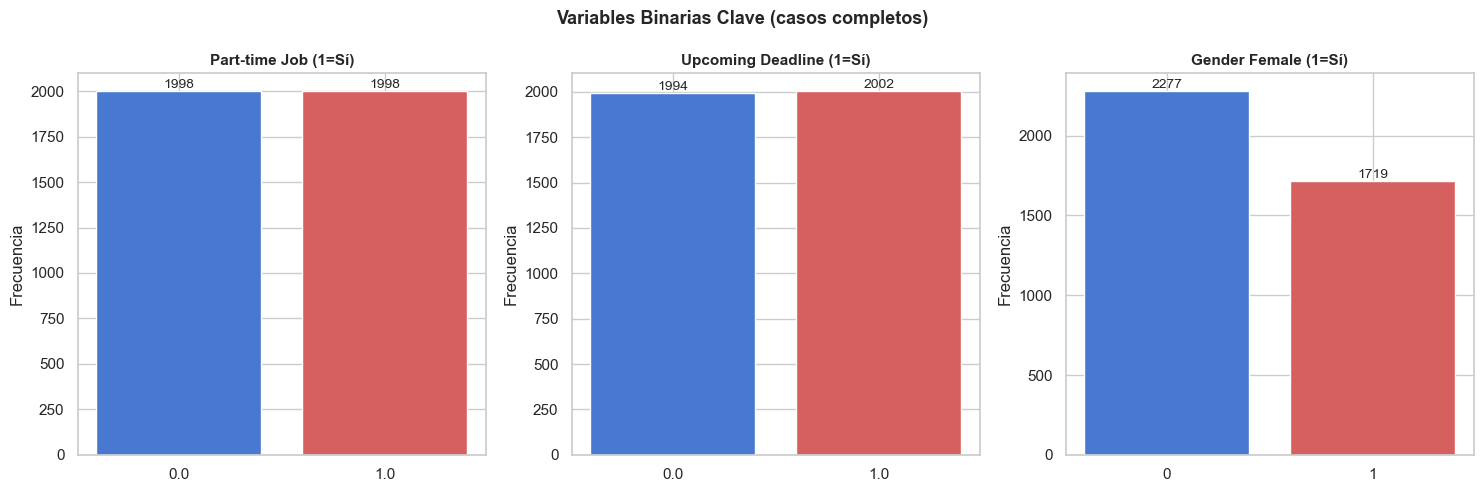

In [18]:
# ── Figura 1: Variables categóricas (reconstruidas desde dummies) ──────────
# gender, academic_level e internet_quality fueron eliminadas al crear dummies,
# por lo que se reconstruyen sus distribuciones a partir de las columnas dummy.

gender_counts = pd.Series({
    'Male':         int(((df_clean['gender_Female']==0) & (df_clean['gender_Other']==0)).sum()),
    'Female':       int(df_clean['gender_Female'].sum()),
    'Other':        int(df_clean['gender_Other'].sum())
})
acad_counts = pd.Series({
    'High_School':   int(((df_clean['academic_Undergraduate']==0) & (df_clean['academic_Postgraduate']==0)).sum()),
    'Undergraduate': int(df_clean['academic_Undergraduate'].sum()),
    'Postgraduate':  int(df_clean['academic_Postgraduate'].sum())
})
inet_counts = pd.Series({
    'Good':    int(((df_clean['internet_Average']==0) & (df_clean['internet_Poor']==0)).sum()),
    'Average': int(df_clean['internet_Average'].sum()),
    'Poor':    int(df_clean['internet_Poor'].sum())
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = ['#4878CF', '#D65F5F', '#6ACC65']

for ax, counts, title in zip(
    axes,
    [gender_counts, acad_counts, inet_counts],
    ['Género', 'Nivel Académico', 'Calidad de Internet']
):
    bars = ax.bar(counts.index, counts.values,
                  color=palette[:len(counts)], edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    for bar in bars:
        ax.annotate(f'{int(bar.get_height())}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Distribución de Variables Categóricas (casos completos)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Figura 2: Variables binarias clave ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ['part_time_job', 'upcoming_deadline', 'gender_Female'],
    ['Part-time Job (1=Sí)', 'Upcoming Deadline (1=Sí)', 'Gender Female (1=Sí)']
):
    counts = df_clean[col].value_counts().sort_index()
    bars   = ax.bar(counts.index.astype(str), counts.values,
                    color=['#4878CF', '#D65F5F'], edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    for bar in bars:
        ax.annotate(f'{int(bar.get_height())}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Variables Binarias Clave (casos completos)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 1.F  Análisis de Correlación y VIF

In [19]:
df_obs_corr = df_clean[df_clean['took_exam'].notna()]
corr_bin = (df_obs_corr[feature_cols+['took_exam']].corr()['took_exam']
            .drop('took_exam').sort_values(key=abs,ascending=False))
print('Correlación con took_exam')
print(corr_bin.round(4).to_string())
print()
df_cnt_c = df_clean[df_clean['took_exam']==1]
corr_cnt = (df_cnt_c[feature_cols+['exam_score']].corr()['exam_score']
            .drop('exam_score').sort_values(key=abs,ascending=False))
print('Correlación con exam_score')
print(corr_cnt.round(4).to_string())

Correlación con took_exam
productivity_score        0.4755
focus_index               0.4084
mental_health_score       0.2841
study_hours               0.2782
burnout_level            -0.2295
sleep_hours               0.1451
upcoming_deadline        -0.0951
part_time_job            -0.0896
screen_time_hours        -0.0892
gaming_hours             -0.0505
social_media_hours       -0.0503
self_study_hours          0.0479
academic_Undergraduate    0.0446
caffeine_intake_mg       -0.0388
age                      -0.0190
exercise_hours            0.0158
academic_Postgraduate    -0.0105
internet_Average          0.0099
gender_Other              0.0087
internet_Poor            -0.0086
gender_Female            -0.0084
online_classes_hours     -0.0071

Correlación con exam_score
productivity_score        0.8639
focus_index               0.7118
mental_health_score       0.5064
study_hours               0.4599
burnout_level            -0.3703
sleep_hours               0.2176
upcoming_deadline     

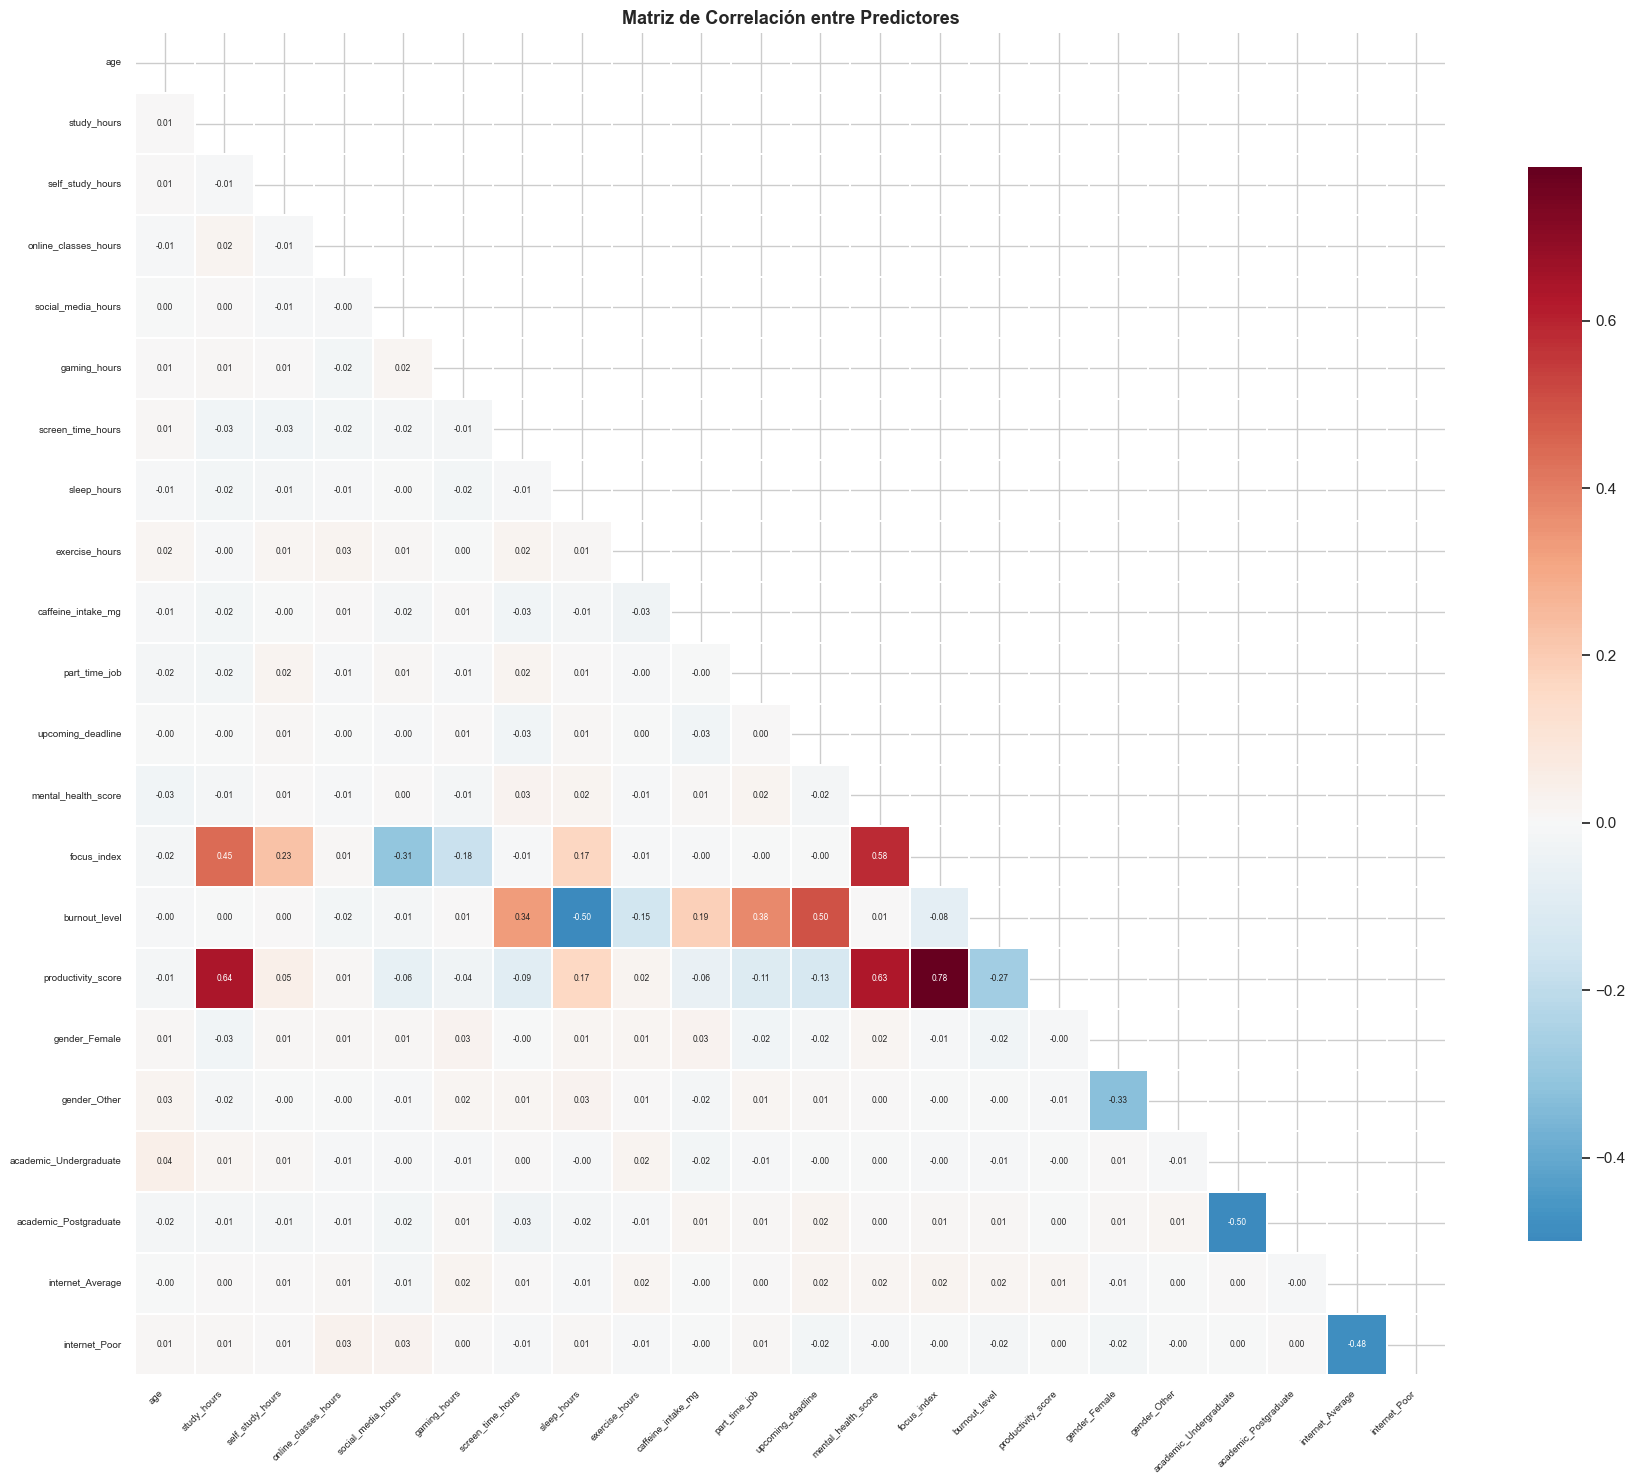

In [20]:
corr_m = df_clean[feature_cols].corr()
plt.figure(figsize=(18,15))
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m,mask=mask,annot=True,fmt='.2f',cmap='RdBu_r',center=0,
            linewidths=0.3,cbar_kws={'shrink':0.8},annot_kws={'size':6})
plt.title('Matriz de Correlación entre Predictores', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

In [21]:
X_vif  = sm.add_constant(df_clean[feature_cols].dropna())
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df['Variable']!='const'].sort_values('VIF',ascending=False)
print(vif_df.to_string(index=False))
print('\nVIF<5: sin problema | 5-10: moderado | >10: grave')

              Variable     VIF
    productivity_score 11.5419
         burnout_level  6.1918
   mental_health_score  5.2560
           study_hours  5.1784
           focus_index  4.5624
           sleep_hours  2.4617
     upcoming_deadline  2.4548
         part_time_job  1.7509
     screen_time_hours  1.6625
    social_media_hours  1.3647
 academic_Postgraduate  1.3389
academic_Undergraduate  1.3378
         internet_Poor  1.3131
      internet_Average  1.3108
    caffeine_intake_mg  1.2199
      self_study_hours  1.2085
         gender_Female  1.1293
          gender_Other  1.1260
        exercise_hours  1.1179
          gaming_hours  1.1142
  online_classes_hours  1.0060
                   age  1.0048

VIF<5: sin problema | 5-10: moderado | >10: grave


---
## Funciones Auxiliares

In [22]:
def backward_ols(X, y, thr=0.05):
    feats = list(X.columns)
    while feats:
        res = sm.OLS(y, sm.add_constant(X[feats])).fit(cov_type='HC3')
        pv  = res.pvalues.drop('const', errors='ignore')
        if pv.max() > thr: feats.remove(pv.idxmax())
        else: break
    return res, feats


def backward_mle(X, y, Cls, thr=0.05):
    feats = list(X.columns)
    while feats:
        try: res = Cls(y, sm.add_constant(X[feats])).fit(disp=0, maxiter=500)
        except: res = Cls(y, sm.add_constant(X[feats])).fit(method='bfgs',maxiter=1000,disp=0)
        pv = res.pvalues.drop(['const','alpha'], errors='ignore')
        if len(pv)==0: break
        if pv.max()>thr: feats.remove(pv.idxmax())
        else: break
    return res, feats


def irr_table(model):
    ci = model.conf_int()
    return pd.DataFrame({
        'IRR': np.exp(model.params),
        'IC 2.5%': np.exp(ci.iloc[:,0]),
        'IC 97.5%': np.exp(ci.iloc[:,1]),
        'p-value': model.pvalues
    }).drop(index=['const','alpha'], errors='ignore')


def marginal_effect_cnt(model, X):
    mu_bar = model.predict(sm.add_constant(X)).mean()
    return model.params.drop(['const','alpha'], errors='ignore') * mu_bar


def poisson_deviance(model, y):
    mu = model.predict()
    with np.errstate(divide='ignore', invalid='ignore'):
        term = np.where(y > 0, y * np.log(y / mu), 0)
    return 2 * np.sum(term - (y - mu))


def stars(p): return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))


def sig_txt(p):
    if p<0.01: return 'estadísticamente significativo al 1%'
    if p<0.05: return 'estadísticamente significativo al 5%'
    if p<0.10: return 'estadísticamente significativo al 10%'
    return 'NO estadísticamente significativo al 10%'


def robustness_table(models_dict, all_vars):
    rows = []
    for v in sorted(all_vars):
        row = {'Variable': v}
        for name, (model, sel_vars) in models_dict.items():
            if v not in sel_vars: row[name] = '—'
            else:
                p = model.pvalues.get(v, 1.0)
                row[name] = stars(p) if p < 0.10 else 'ns'
        rows.append(row)
    return pd.DataFrame(rows).set_index('Variable')

print('Funciones cargadas.')

Funciones cargadas.


---
## Pregunta 2 — Modelo de Probabilidad Lineal (MPL / MCO)

$$P(\text{took\_exam}_i=1)=\beta_0+\sum_k\beta_k X_{ki}+\varepsilon_i$$

**Muestra:** casos completos con `took_exam` conocido.  
**Errores estándar HC3:** robustos a heterocedasticidad estructural del MPL ($\text{Var}(\varepsilon_i)=p_i(1-p_i)$).  
**Selección:** eliminación hacia atrás, umbral $p>0.05$.

In [23]:
df_bin  = df_clean[df_clean['took_exam'].notna()].copy()
y_bin   = df_bin['took_exam'].astype(float)
X_bin   = df_bin[feature_cols]
n_bin   = len(df_bin)
n1_bin  = int(y_bin.sum()); n0_bin = int((y_bin==0).sum())
nobs_bin= n1_bin + n0_bin
print(f'Muestra: {n_bin} obs | took_exam=1: {n1_bin} ({100*n1_bin/nobs_bin:.1f}%) '
      f'| took_exam=0: {n0_bin} ({100*n0_bin/nobs_bin:.1f}%)')
print(f'(vs. 4.912 con imputación — se pierden {4912-n_bin} obs por listwise deletion)')

Muestra: 3975 obs | took_exam=1: 3630 (91.3%) | took_exam=0: 345 (8.7%)
(vs. 4.912 con imputación — se pierden 937 obs por listwise deletion)


In [24]:
ols_full = sm.OLS(y_bin, sm.add_constant(X_bin)).fit(cov_type='HC3')
print('MPL — Modelo Completo')
print(ols_full.summary2().tables[1].round(4))
print(f'\nR²={ols_full.rsquared:.4f} | AIC={ols_full.aic:.2f} | BIC={ols_full.bic:.2f}')

MPL — Modelo Completo
                         Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const                   0.7365    0.0607 12.1404 0.0000  0.6176  0.8554
age                    -0.0014    0.0014 -1.0049 0.3150 -0.0040  0.0013
study_hours             0.0008    0.0048  0.1625 0.8709 -0.0087  0.0102
self_study_hours       -0.0000    0.0036 -0.0079 0.9937 -0.0071  0.0070
online_classes_hours   -0.0041    0.0039 -1.0412 0.2978 -0.0117  0.0036
social_media_hours      0.0024    0.0031  0.7850 0.4325 -0.0037  0.0086
gaming_hours           -0.0032    0.0038 -0.8461 0.3975 -0.0106  0.0042
screen_time_hours      -0.0017    0.0020 -0.8218 0.4112 -0.0056  0.0023
sleep_hours             0.0005    0.0052  0.0952 0.9242 -0.0097  0.0107
exercise_hours         -0.0041    0.0057 -0.7098 0.4779 -0.0153  0.0072
caffeine_intake_mg      0.0000    0.0000  0.3718 0.7100 -0.0000  0.0001
part_time_job          -0.0029    0.0104 -0.2785 0.7806 -0.0232  0.0174
upcoming_deadline       0.0068    0.0118  

In [25]:
ols_fin, ols_vars = backward_ols(X_bin, y_bin)
print(f'MPL — Modelo Final ({len(ols_vars)} variables)')
print(f'Variables: {ols_vars}\n')
print(ols_fin.summary2().tables[1].round(4))
print(f'\nR²={ols_fin.rsquared:.4f} | R²_adj={ols_fin.rsquared_adj:.4f}')
print(f'AIC={ols_fin.aic:.2f} | BIC={ols_fin.bic:.2f}')

MPL — Modelo Final (4 variables)
Variables: ['focus_index', 'burnout_level', 'productivity_score', 'academic_Undergraduate']

                         Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const                   0.6972    0.0211 33.0559 0.0000  0.6558  0.7385
focus_index             0.0039    0.0007  5.7135 0.0000  0.0026  0.0053
burnout_level          -0.0025    0.0003 -8.5079 0.0000 -0.0031 -0.0020
productivity_score      0.0056    0.0004 12.7618 0.0000  0.0047  0.0064
academic_Undergraduate  0.0264    0.0080  3.3094 0.0009  0.0108  0.0421

R²=0.2458 | R²_adj=0.2451
AIC=92.38 | BIC=123.82


Predicciones fuera [0,1]: 1106 (27.82%)
→ Limitación estructural del MPL.



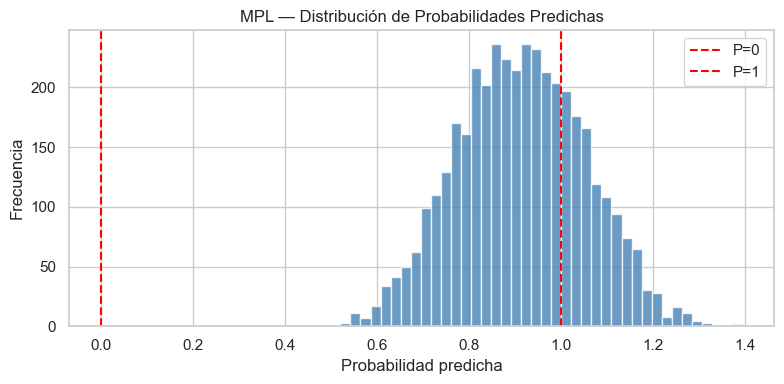

Matriz de Confusión — MPL
                 Pred: No rindió  Pred: Rindió
Real: No rindió                0           345
Real: Rindió                   0          3630
              precision    recall  f1-score   support

   No rindió       0.00      0.00      0.00       345
      Rindió       0.91      1.00      0.95      3630

    accuracy                           0.91      3975
   macro avg       0.46      0.50      0.48      3975
weighted avg       0.83      0.91      0.87      3975



In [26]:
pred_ols  = ols_fin.predict()
n_out_ols = int((pred_ols<0).sum() + (pred_ols>1).sum())
print(f'Predicciones fuera [0,1]: {n_out_ols} ({100*n_out_ols/len(pred_ols):.2f}%)')
print('→ Limitación estructural del MPL.\n')

plt.figure(figsize=(8,4))
plt.hist(pred_ols, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', ls='--', label='P=0')
plt.axvline(1, color='red', ls='--', label='P=1')
plt.xlabel('Probabilidad predicha'); plt.ylabel('Frecuencia')
plt.title('MPL — Distribución de Probabilidades Predichas')
plt.legend(); plt.tight_layout(); plt.show()

pred_ols_bin = (pred_ols>=0.5).astype(int)
print('Matriz de Confusión — MPL')
cm_ols = confusion_matrix(y_bin.astype(int), pred_ols_bin)
print(pd.DataFrame(cm_ols,index=['Real: No rindió','Real: Rindió'],
                   columns=['Pred: No rindió','Pred: Rindió']))
print(classification_report(y_bin.astype(int), pred_ols_bin,
      target_names=['No rindió','Rindió']))

### Interpretación del MPL

Cada coeficiente $\hat{\beta}_k$ mide el cambio en **puntos porcentuales (p.p.)** en la probabilidad de rendir el examen ante un aumento de una unidad en $X_k$, manteniendo constantes todas las demás variables (*ceteris paribus*). El efecto es constante a lo largo de toda la distribución de $X_k$.

In [27]:
print('INTERPRETACIÓN COMPLETA — MPL')
coef_ols = ols_fin.params.drop('const')
pval_ols = ols_fin.pvalues.drop('const')
ci_ols   = ols_fin.conf_int().drop('const')

for v in ols_vars:
    b=coef_ols[v]; p=pval_ols[v]; lo=ci_ols.loc[v,0]; hi=ci_ols.loc[v,1]
    dir_='incrementa' if b>0 else 'reduce'
    print(f'\n  ▸ {v}')
    print(f'    β={b:.4f} {stars(p)} | p={p:.4f} | IC95%: [{lo:.4f},{hi:.4f}]')
    print(f'    Manteniendo constantes las demás variables, un aumento de 1 unidad en')
    print(f'    "{v}" {dir_} la probabilidad de rendir el examen en {abs(b)*100:.2f} p.p.')
    print(f'    ({sig_txt(p)}.)')

INTERPRETACIÓN COMPLETA — MPL

  ▸ focus_index
    β=0.0039 *** | p=0.0000 | IC95%: [0.0026,0.0053]
    Manteniendo constantes las demás variables, un aumento de 1 unidad en
    "focus_index" incrementa la probabilidad de rendir el examen en 0.39 p.p.
    (estadísticamente significativo al 1%.)

  ▸ burnout_level
    β=-0.0025 *** | p=0.0000 | IC95%: [-0.0031,-0.0020]
    Manteniendo constantes las demás variables, un aumento de 1 unidad en
    "burnout_level" reduce la probabilidad de rendir el examen en 0.25 p.p.
    (estadísticamente significativo al 1%.)

  ▸ productivity_score
    β=0.0056 *** | p=0.0000 | IC95%: [0.0047,0.0064]
    Manteniendo constantes las demás variables, un aumento de 1 unidad en
    "productivity_score" incrementa la probabilidad de rendir el examen en 0.56 p.p.
    (estadísticamente significativo al 1%.)

  ▸ academic_Undergraduate
    β=0.0264 *** | p=0.0009 | IC95%: [0.0108,0.0421]
    Manteniendo constantes las demás variables, un aumento de 1 unidad en


---
## Pregunta 3 — Modelo Probit

$$P(\text{took\_exam}_i=1)=\Phi(X_i'\beta)$$

Estimado por Máxima Verosimilitud. Interpretación mediante **AME** (Efectos Marginales Promedio): cambio promedio en la probabilidad ante un aumento unitario en $X_k$, evaluado en los valores observados de cada individuo y promediado sobre la muestra.

In [28]:
probit_full = sm.Probit(y_bin, sm.add_constant(X_bin)).fit(disp=0, maxiter=300)
print('Probit — Modelo Completo')
print(probit_full.summary2().tables[1].round(4))
print(f'\nPseudo-R²={probit_full.prsquared:.4f} | AIC={probit_full.aic:.2f}')

Probit — Modelo Completo
                         Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const                  -0.5296    0.6901 -0.7674 0.4428 -1.8821  0.8230
age                     0.0053    0.0160  0.3309 0.7407 -0.0261  0.0367
study_hours            -0.0528    0.0589 -0.8965 0.3700 -0.1682  0.0626
self_study_hours       -0.0187    0.0445 -0.4212 0.6736 -0.1060  0.0685
online_classes_hours   -0.0238    0.0479 -0.4959 0.6199 -0.1177  0.0701
social_media_hours      0.0384    0.0367  1.0471 0.2951 -0.0335  0.1103
gaming_hours            0.0293    0.0419  0.6979 0.4853 -0.0529  0.1115
screen_time_hours      -0.0391    0.0238 -1.6425 0.1005 -0.0857  0.0076
sleep_hours             0.0192    0.0601  0.3190 0.7497 -0.0986  0.1370
exercise_hours         -0.0024    0.0683 -0.0352 0.9719 -0.1363  0.1315
caffeine_intake_mg     -0.0000    0.0003 -0.0567 0.9548 -0.0007  0.0007
part_time_job          -0.0606    0.1198 -0.5058 0.6130 -0.2953  0.1741
upcoming_deadline       0.1031    0.146

In [29]:
probit_fin, probit_vars = backward_mle(X_bin, y_bin, sm.Probit)
print(f'Probit — Modelo Final ({len(probit_vars)} variables)')
print(f'Variables: {probit_vars}\n')
print(probit_fin.summary2().tables[1].round(4))
print(f'\nPseudo-R²={probit_fin.prsquared:.4f} | AIC={probit_fin.aic:.2f} | BIC={probit_fin.bic:.2f}')

Probit — Modelo Final (4 variables)
Variables: ['focus_index', 'burnout_level', 'productivity_score', 'academic_Undergraduate']

                         Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const                  -0.2221    0.2100 -1.0575 0.2903 -0.6336  0.1895
focus_index             0.0504    0.0076  6.6328 0.0000  0.0355  0.0653
burnout_level          -0.0367    0.0037 -9.8648 0.0000 -0.0440 -0.0294
productivity_score      0.1001    0.0062 16.0222 0.0000  0.0878  0.1123
academic_Undergraduate  0.2623    0.0986  2.6604 0.0078  0.0691  0.4556

Pseudo-R²=0.5878 | AIC=976.86 | BIC=1008.30


In [30]:
probit_ame = probit_fin.get_margeff(at='overall')
print('AME — Probit'); print(probit_ame.summary())

pred_probit = (probit_fin.predict()>=0.5).astype(int)
print('\nMatriz de Confusión — Probit')
cm_p = confusion_matrix(y_bin.astype(int), pred_probit)
print(pd.DataFrame(cm_p,index=['Real: No rindió','Real: Rindió'],
                   columns=['Pred: No rindió','Pred: Rindió']))
rep_p = classification_report(y_bin.astype(int), pred_probit,
        target_names=['No rindió','Rindió'], output_dict=True)
print(classification_report(y_bin.astype(int), pred_probit,
      target_names=['No rindió','Rindió']))
print(f'Recall minoritaria: {rep_p["No rindió"]["recall"]:.2f} | Accuracy: {rep_p["accuracy"]:.2%}')

AME — Probit
       Probit Marginal Effects       
Dep. Variable:              took_exam
Method:                          dydx
At:                           overall
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
focus_index                0.0034      0.000      6.838      0.000       0.002       0.004
burnout_level             -0.0025      0.000    -10.673      0.000      -0.003      -0.002
productivity_score         0.0067      0.000     20.369      0.000       0.006       0.007
academic_Undergraduate     0.0176      0.007      2.678      0.007       0.005       0.031

Matriz de Confusión — Probit
                 Pred: No rindió  Pred: Rindió
Real: No rindió              198           147
Real: Rindió                  61          3569
              precision    recall  f1-score   support

   No rindió       0.76      0.57      0.66       345
      Rin

### Interpretación del Probit

Los **AME** expresan el cambio promedio en la probabilidad de rendir el examen ante un aumento de una unidad en el regresor, capturando la no-linealidad del modelo (efectos menores en los extremos, mayores en el centro de la distribución).

In [31]:
print('INTERPRETACIÓN COMPLETA — PROBIT (AME)')

ame_pf = probit_ame.summary_frame()
for v in probit_vars:
    if v not in ame_pf.index: continue
    ame=ame_pf.loc[v,'dy/dx']; p=ame_pf.loc[v,'Pr(>|z|)']; se=ame_pf.loc[v,'Std. Err.']
    dir_='incrementa' if ame>0 else 'reduce'
    print(f'\n  ▸ {v}')
    print(f'    AME={ame:.4f} {stars(p)} | SE={se:.4f} | p={p:.4f}')
    print(f'    En promedio sobre la muestra, un aumento de 1 unidad en "{v}"')
    print(f'    {dir_} la probabilidad promedio de rendir en {abs(ame)*100:.2f} p.p.')
    print(f'    ({sig_txt(p)}, evaluado en los valores observados de cada individuo.)')

INTERPRETACIÓN COMPLETA — PROBIT (AME)

  ▸ focus_index
    AME=0.0034 *** | SE=0.0005 | p=0.0000
    En promedio sobre la muestra, un aumento de 1 unidad en "focus_index"
    incrementa la probabilidad promedio de rendir en 0.34 p.p.
    (estadísticamente significativo al 1%, evaluado en los valores observados de cada individuo.)

  ▸ burnout_level
    AME=-0.0025 *** | SE=0.0002 | p=0.0000
    En promedio sobre la muestra, un aumento de 1 unidad en "burnout_level"
    reduce la probabilidad promedio de rendir en 0.25 p.p.
    (estadísticamente significativo al 1%, evaluado en los valores observados de cada individuo.)

  ▸ productivity_score
    AME=0.0067 *** | SE=0.0003 | p=0.0000
    En promedio sobre la muestra, un aumento de 1 unidad en "productivity_score"
    incrementa la probabilidad promedio de rendir en 0.67 p.p.
    (estadísticamente significativo al 1%, evaluado en los valores observados de cada individuo.)

  ▸ academic_Undergraduate
    AME=0.0176 *** | SE=0.0066 | p=0

---
## Pregunta 4 — Modelo Logit

$$P(\text{took\_exam}_i=1)=\frac{e^{X_i'\beta}}{1+e^{X_i'\beta}}$$

Dos métricas complementarias: **AME** (cambio en p.p.) y **Odds Ratio** ($e^{\hat{\beta}}$: factor multiplicativo sobre las *odds*).

In [32]:
logit_full = sm.Logit(y_bin, sm.add_constant(X_bin)).fit(disp=0, maxiter=300)
print('Logit — Modelo Completo')
print(logit_full.summary2().tables[1].round(4))
print(f'\nPseudo-R²={logit_full.prsquared:.4f} | AIC={logit_full.aic:.2f}')

Logit — Modelo Completo
                         Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const                  -1.1494    1.2626 -0.9104 0.3626 -3.6241  1.3252
age                     0.0115    0.0295  0.3920 0.6951 -0.0462  0.0693
study_hours            -0.1131    0.1076 -1.0510 0.2933 -0.3240  0.0978
self_study_hours       -0.0294    0.0810 -0.3634 0.7163 -0.1881  0.1292
online_classes_hours   -0.0186    0.0884 -0.2107 0.8331 -0.1920  0.1547
social_media_hours      0.0659    0.0669  0.9852 0.3245 -0.0652  0.1969
gaming_hours            0.0550    0.0764  0.7209 0.4710 -0.0946  0.2047
screen_time_hours      -0.0641    0.0435 -1.4735 0.1406 -0.1493  0.0211
sleep_hours             0.0427    0.1110  0.3843 0.7008 -0.1749  0.2603
exercise_hours         -0.0154    0.1256 -0.1224 0.9026 -0.2616  0.2309
caffeine_intake_mg      0.0001    0.0006  0.0966 0.9230 -0.0012  0.0013
part_time_job          -0.0932    0.2206 -0.4225 0.6727 -0.5255  0.3391
upcoming_deadline       0.2970    0.2692

In [33]:
logit_fin, logit_vars = backward_mle(X_bin, y_bin, sm.Logit)
print(f'Logit — Modelo Final ({len(logit_vars)} variables)')
print(f'Variables: {logit_vars}\n')
print(logit_fin.summary2().tables[1].round(4))
print(f'\nPseudo-R²={logit_fin.prsquared:.4f} | AIC={logit_fin.aic:.2f} | BIC={logit_fin.bic:.2f}')

Logit — Modelo Final (5 variables)
Variables: ['upcoming_deadline', 'focus_index', 'burnout_level', 'productivity_score', 'academic_Undergraduate']

                         Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
const                  -0.3311    0.3879 -0.8537 0.3933 -1.0914  0.4291
upcoming_deadline       0.4279    0.1997  2.1429 0.0321  0.0365  0.8193
focus_index             0.0922    0.0142  6.5095 0.0000  0.0644  0.1199
burnout_level          -0.0746    0.0079 -9.4111 0.0000 -0.0901 -0.0590
productivity_score      0.1858    0.0120 15.5359 0.0000  0.1624  0.2092
academic_Undergraduate  0.4741    0.1809  2.6206 0.0088  0.1195  0.8287

Pseudo-R²=0.5883 | AIC=977.67 | BIC=1015.40


In [34]:
logit_ame = logit_fin.get_margeff(at='overall')
print('AME — Logit'); print(logit_ame.summary())
print()
print('Odds Ratios — Logit')
print(irr_table(logit_fin).round(4))

pred_logit = (logit_fin.predict()>=0.5).astype(int)
print('\n Matriz de Confusión — Logit')
cm_l = confusion_matrix(y_bin.astype(int), pred_logit)
print(pd.DataFrame(cm_l,index=['Real: No rindió','Real: Rindió'],
                   columns=['Pred: No rindió','Pred: Rindió']))
print(classification_report(y_bin.astype(int), pred_logit,
      target_names=['No rindió','Rindió']))

AME — Logit
        Logit Marginal Effects       
Dep. Variable:              took_exam
Method:                          dydx
At:                           overall
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
upcoming_deadline          0.0156      0.007      2.149      0.032       0.001       0.030
focus_index                0.0034      0.000      6.768      0.000       0.002       0.004
burnout_level             -0.0027      0.000    -10.208      0.000      -0.003      -0.002
productivity_score         0.0068      0.000     20.713      0.000       0.006       0.007
academic_Undergraduate     0.0173      0.007      2.643      0.008       0.004       0.030

Odds Ratios — Logit
                          IRR  IC 2.5%  IC 97.5%  p-value
upcoming_deadline      1.5341   1.0372    2.2690   0.0321
focus_index            1.0965   1.0665    1.1274   0.0000
burn

### Interpretación del Logit

**AME:** idéntica interpretación al Probit (cambio en p.p.).  
**OR:** si OR = 1.10, las *odds* de rendir aumentan un 10% por unidad adicional; si OR = 0.85, disminuyen un 15%.

In [35]:
print('INTERPRETACIÓN COMPLETA — LOGIT (AME y Odds Ratios)')

ame_lf = logit_ame.summary_frame()
or_s   = np.exp(logit_fin.params.drop('const'))

for v in logit_vars:
    if v not in ame_lf.index: continue
    ame=ame_lf.loc[v,'dy/dx']; p=ame_lf.loc[v,'Pr(>|z|)']
    OR=or_s[v]; pct=(OR-1)*100
    dir_p='incrementa' if ame>0 else 'reduce'
    dir_o='incrementan' if OR>1 else 'disminuyen'
    print(f'\n  ▸ {v}')
    print(f'    AME={ame:.4f} {stars(p)} | OR={OR:.4f} | p={p:.4f}')
    print(f'    — Probabilidad: 1 unidad adicional en "{v}" {dir_p}')
    print(f'      la prob. promedio de rendir en {abs(ame)*100:.2f} p.p., ceteris paribus.')
    print(f'    — Odds: las odds de rendir el examen {dir_o} en un {abs(pct):.1f}%.')
    print(f'    ({sig_txt(p)}.)')

INTERPRETACIÓN COMPLETA — LOGIT (AME y Odds Ratios)

  ▸ upcoming_deadline
    AME=0.0156 ** | OR=1.5341 | p=0.0316
    — Probabilidad: 1 unidad adicional en "upcoming_deadline" incrementa
      la prob. promedio de rendir en 1.56 p.p., ceteris paribus.
    — Odds: las odds de rendir el examen incrementan en un 53.4%.
    (estadísticamente significativo al 5%.)

  ▸ focus_index
    AME=0.0034 *** | OR=1.0965 | p=0.0000
    — Probabilidad: 1 unidad adicional en "focus_index" incrementa
      la prob. promedio de rendir en 0.34 p.p., ceteris paribus.
    — Odds: las odds de rendir el examen incrementan en un 9.7%.
    (estadísticamente significativo al 1%.)

  ▸ burnout_level
    AME=-0.0027 *** | OR=0.9281 | p=0.0000
    — Probabilidad: 1 unidad adicional en "burnout_level" reduce
      la prob. promedio de rendir en 0.27 p.p., ceteris paribus.
    — Odds: las odds de rendir el examen disminuyen en un 7.2%.
    (estadísticamente significativo al 1%.)

  ▸ productivity_score
    AME=0.00

---
## Pregunta 5 — Comparación MPL, Probit y Logit

### 5.A  Tabla de Efectos Marginales Comparados

In [36]:
ame_pb = probit_fin.get_margeff(at='overall').summary_frame()['dy/dx']
ame_lg = logit_fin.get_margeff(at='overall').summary_frame()['dy/dx']
c_ols  = ols_fin.params.drop('const')
all_v  = sorted(set(ols_vars)|set(probit_vars)|set(logit_vars))
rows   = [{'Variable':v,'MPL (β)':c_ols.get(v,np.nan),
           'Probit (AME)':ame_pb.get(v,np.nan),
           'Logit (AME)':ame_lg.get(v,np.nan)} for v in all_v]
comp = pd.DataFrame(rows).set_index('Variable')
print('Efectos Marginales Comparados (p.p.)')
print(comp.round(4).to_string())

Efectos Marginales Comparados (p.p.)
                        MPL (β)  Probit (AME)  Logit (AME)
Variable                                                  
academic_Undergraduate   0.0264        0.0176       0.0173
burnout_level           -0.0025       -0.0025      -0.0027
focus_index              0.0039        0.0034       0.0034
productivity_score       0.0056        0.0067       0.0068
upcoming_deadline           NaN           NaN       0.0156


In [37]:
print(f'{"Modelo":<12} {"R²/Pseudo-R²":>15} {"Log-Lik":>12} {"AIC":>10} {"BIC":>10}')
print('-'*62)
for name, mdl, r2 in [('MPL',ols_fin,ols_fin.rsquared),
                       ('Probit',probit_fin,probit_fin.prsquared),
                       ('Logit',logit_fin,logit_fin.prsquared)]:
    print(f'{name:<12} {r2:>15.4f} {mdl.llf:>12.2f} {mdl.aic:>10.2f} {mdl.bic:>10.2f}')

Modelo          R²/Pseudo-R²      Log-Lik        AIC        BIC
--------------------------------------------------------------
MPL                   0.2458       -41.19      92.38     123.82
Probit                0.5878      -483.43     976.86    1008.30
Logit                 0.5883      -482.84     977.67    1015.40


### 5.B  Variables Robustas

In [38]:
models_bin  = {'MPL':(ols_fin,ols_vars),'Probit':(probit_fin,probit_vars),'Logit':(logit_fin,logit_vars)}
rob_bin     = robustness_table(models_bin, set(ols_vars)|set(probit_vars)|set(logit_vars))
print('Tabla de Robustez — Modelos Binarios')
print('(*** p<0.01  ** p<0.05  * p<0.10  ns=no sig.  —=no incluida)')
print(rob_bin.to_string()); print()
robust_vars_bin=[v for v in rob_bin.index
                 if all(rob_bin.loc[v,c] not in ['—','ns'] for c in rob_bin.columns)]
print(f'Variables robustas (sig. en los 3): {robust_vars_bin}')

Tabla de Robustez — Modelos Binarios
(*** p<0.01  ** p<0.05  * p<0.10  ns=no sig.  —=no incluida)
                        MPL Probit Logit
Variable                                
academic_Undergraduate  ***    ***   ***
burnout_level           ***    ***   ***
focus_index             ***    ***   ***
productivity_score      ***    ***   ***
upcoming_deadline         —      —    **

Variables robustas (sig. en los 3): ['academic_Undergraduate', 'burnout_level', 'focus_index', 'productivity_score']


### 5.C  Discusión

**1. MPL vs Probit/Logit:** El MPL impone efectos marginales constantes para todos los niveles de $X$, generando predicciones fuera de $[0,1]$ y violando sistemáticamente la homocedasticidad. Probit y Logit garantizan predicciones en $[0,1]$ mediante funciones $S$.

**2. Probit vs Logit:** Difieren en el supuesto distribucional (normal estándar vs. logística). Con n ≈ 3.975, los AME convergen y las diferencias son numéricamente irrelevantes.

**3. Modelo recomendado:** **Logit** — coeficientes con interpretación directa como log-odds, estándar en la literatura económica, y garantiza $P\in[0,1]$.

**4. Desbalance de clases (~91/9%):** los tres modelos predicen casi siempre la clase mayoritaria. Limitación estructural del dataset.

**5. Variables robustas:** las listadas arriba son las más confiables — su efecto es independiente del modelo elegido.

---
## Pregunta 6 — Modelo Poisson para la Nota del Examen

**Muestra:** casos completos que rindieron el examen (`took_exam = 1`).  
**Variable dependiente:** `exam_score_int` = `exam_score` redondeado.  
**Limitación:** `exam_score` es continua, no un conteo natural. El redondeo es la transformación mínima para cumplir el requisito formal.

Muestra: 3630 obs
count   3630.0000
mean      20.5204
std       11.2980
min        1.0000
25%       12.0000
50%       19.0000
75%       28.0000
max       64.0000
Name: exam_score_int, dtype: float64

Media=20.5204 | Varianza=127.6456 | Var/Media=6.2204
→ Var/Media >> 1: sobredispersión evidente



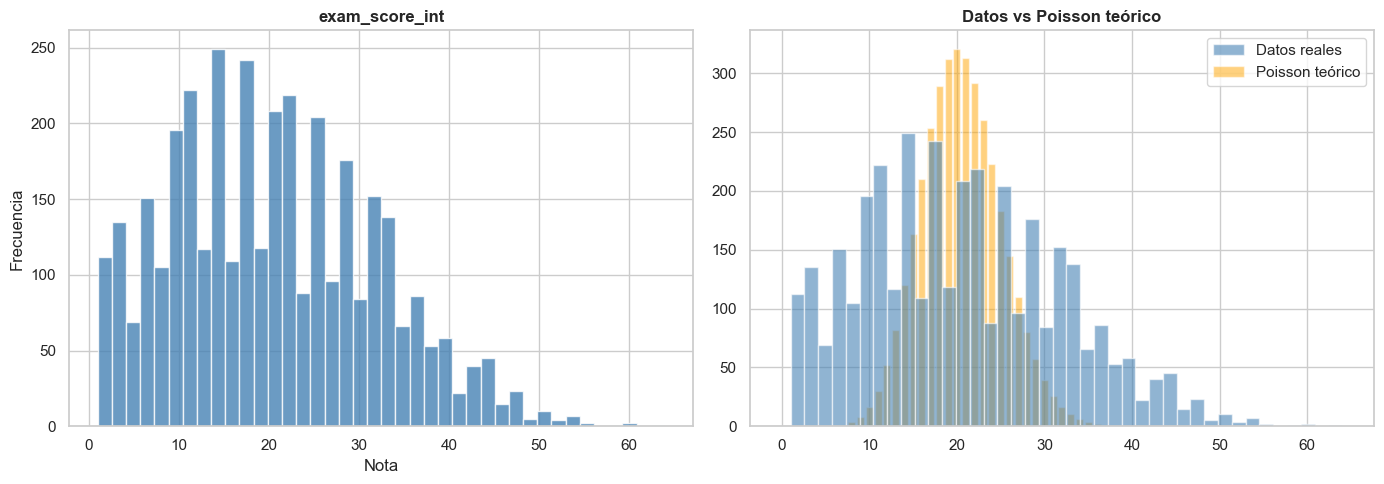

In [39]:
df_cnt = df_clean[df_clean['took_exam']==1].copy()
df_cnt['exam_score_int'] = df_cnt['exam_score'].round().astype(int)
y_cnt  = df_cnt['exam_score_int']
X_cnt  = df_cnt[feature_cols]
n_cnt  = len(df_cnt)
media_y= y_cnt.mean(); var_y = y_cnt.var()
ratio_var_med = var_y / media_y

print(f'Muestra: {n_cnt} obs')
print(y_cnt.describe())
print(f'\nMedia={media_y:.4f} | Varianza={var_y:.4f} | Var/Media={ratio_var_med:.4f}')
print('→ Var/Media >> 1: sobredispersión evidente\n')

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(y_cnt,bins=40,color='steelblue',edgecolor='white',alpha=0.8)
axes[0].set_title('exam_score_int',fontweight='bold')
axes[0].set_xlabel('Nota'); axes[0].set_ylabel('Frecuencia')
lam=y_cnt.mean(); x_r=np.arange(0,y_cnt.max()+1)
axes[1].bar(x_r,stats.poisson.pmf(x_r,lam)*len(y_cnt),alpha=0.5,color='orange',label='Poisson teórico')
axes[1].hist(y_cnt,bins=40,alpha=0.6,color='steelblue',label='Datos reales')
axes[1].set_title('Datos vs Poisson teórico',fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()

In [40]:
pois_full = sm.Poisson(y_cnt, sm.add_constant(X_cnt)).fit(disp=0, maxiter=300)
print('Poisson — Modelo Completo')
print(pois_full.summary2().tables[1].round(4))
dev_full_p=poisson_deviance(pois_full,y_cnt); gl_full_p=len(y_cnt)-pois_full.df_model-1
print(f'\nLog-Lik={pois_full.llf:.4f} | Devianza/gl={dev_full_p/gl_full_p:.4f}')
print('(Devianza/gl>>1 → sobredispersión)')

Poisson — Modelo Completo
                         Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const                   2.0711    0.0573  36.1476 0.0000  1.9588  2.1834
age                    -0.0003    0.0013  -0.2435 0.8076 -0.0028  0.0022
study_hours             0.0064    0.0046   1.3930 0.1636 -0.0026  0.0154
self_study_hours       -0.0045    0.0034  -1.3031 0.1925 -0.0112  0.0022
online_classes_hours   -0.0041    0.0037  -1.1204 0.2625 -0.0114  0.0031
social_media_hours      0.0019    0.0029   0.6677 0.5043 -0.0037  0.0076
gaming_hours            0.0028    0.0035   0.7848 0.4326 -0.0041  0.0097
screen_time_hours       0.0019    0.0019   0.9894 0.3225 -0.0019  0.0057
sleep_hours            -0.0065    0.0050  -1.3154 0.1884 -0.0162  0.0032
exercise_hours         -0.0075    0.0054  -1.3819 0.1670 -0.0181  0.0031
caffeine_intake_mg      0.0000    0.0000   1.2581 0.2084 -0.0000  0.0001
part_time_job           0.0110    0.0098   1.1192 0.2631 -0.0082  0.0302
upcoming_deadline      -0

In [41]:
pois_fin, pois_vars = backward_mle(X_cnt, y_cnt, sm.Poisson)
print(f'Poisson — Modelo Final ({len(pois_vars)} variables)')
print(f'Variables: {pois_vars}\n')
print(pois_fin.summary2().tables[1].round(4))
dev_fin_p=poisson_deviance(pois_fin,y_cnt); gl_fin_p=len(y_cnt)-pois_fin.df_model-1
dev_fin_gl = dev_fin_p/gl_fin_p
print(f'\nLog-Lik={pois_fin.llf:.4f} | AIC={pois_fin.aic:.2f} | BIC={pois_fin.bic:.2f}')
print(f'Devianza={dev_fin_p:.2f} | gl={gl_fin_p} | Devianza/gl={dev_fin_gl:.4f}')
print()
print('IRR — Poisson')
print(irr_table(pois_fin).round(4))

Poisson — Modelo Final (5 variables)
Variables: ['upcoming_deadline', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score']

                      Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const                2.0114    0.0190 105.9875 0.0000  1.9742  2.0486
upcoming_deadline   -0.0266    0.0085  -3.1464 0.0017 -0.0432 -0.0100
mental_health_score  0.0070    0.0017   4.0602 0.0000  0.0036  0.0104
focus_index          0.0135    0.0006  21.6608 0.0000  0.0123  0.0147
burnout_level       -0.0088    0.0003 -27.5908 0.0000 -0.0094 -0.0081
productivity_score   0.0211    0.0004  52.0113 0.0000  0.0203  0.0219

Log-Lik=-11632.4080 | AIC=23276.82 | BIC=23314.00
Devianza=6337.94 | gl=3624.0 | Devianza/gl=1.7489

IRR — Poisson
                       IRR  IC 2.5%  IC 97.5%  p-value
upcoming_deadline   0.9737   0.9577    0.9900   0.0017
mental_health_score 1.0071   1.0036    1.0105   0.0000
focus_index         1.0136   1.0124    1.0148   0.0000
burnout_level       0.9913

### Interpretación del Modelo Poisson

**IRR** ($e^{\hat{\beta}_k}$): factor multiplicativo sobre la nota esperada.  
**EM en niveles** ($\hat{\beta}_k \cdot \bar{\mu}$): cambio en puntos de nota.  
**Advertencia:** errores estándar subestimados por sobredispersión. Los p-values son artificialmente pequeños. La NB (Q8) corrige esto.

In [42]:
irr_p =irr_table(pois_fin)
me_p  =marginal_effect_cnt(pois_fin,X_cnt[pois_vars])
mu_med=pois_fin.predict().mean()

print('INTERPRETACIÓN COMPLETA — POISSON')

print(f'Nota media predicha: {mu_med:.2f} pts')
print('ADVERTENCIA: errores estándar subestimados. Ver P7 y P8.\n')

for v in pois_vars:
    if v not in irr_p.index: continue
    irr=irr_p.loc[v,'IRR']; p=irr_p.loc[v,'p-value']
    me=me_p.get(v,np.nan); pct=(irr-1)*100
    dir_='aumenta' if irr>1 else 'reduce'
    print(f'  ▸ {v}')
    print(f'    IRR={irr:.4f} {stars(p)} | EM={me:+.4f} pts | p={p:.4f}')
    print(f'    — IRR: 1 unidad adicional en "{v}" {dir_} la nota esperada')
    print(f'      en {abs(pct):.2f}%, ceteris paribus.')
    print(f'    — En niveles: {me:+.4f} pts sobre la nota media de {mu_med:.2f}.')
    print(f'    ({sig_txt(p)} — sujeto a sobredispersión.)')
    print()

INTERPRETACIÓN COMPLETA — POISSON
Nota media predicha: 20.52 pts
ADVERTENCIA: errores estándar subestimados. Ver P7 y P8.

  ▸ upcoming_deadline
    IRR=0.9737 *** | EM=-0.5463 pts | p=0.0017
    — IRR: 1 unidad adicional en "upcoming_deadline" reduce la nota esperada
      en 2.63%, ceteris paribus.
    — En niveles: -0.5463 pts sobre la nota media de 20.52.
    (estadísticamente significativo al 1% — sujeto a sobredispersión.)

  ▸ mental_health_score
    IRR=1.0071 *** | EM=+0.1442 pts | p=0.0000
    — IRR: 1 unidad adicional en "mental_health_score" aumenta la nota esperada
      en 0.71%, ceteris paribus.
    — En niveles: +0.1442 pts sobre la nota media de 20.52.
    (estadísticamente significativo al 1% — sujeto a sobredispersión.)

  ▸ focus_index
    IRR=1.0136 *** | EM=+0.2772 pts | p=0.0000
    — IRR: 1 unidad adicional en "focus_index" aumenta la nota esperada
      en 1.36%, ceteris paribus.
    — En niveles: +0.2772 pts sobre la nota media de 20.52.
    (estadísticamente 

---
## Pregunta 7 — Análisis de Sobredispersión y Alpha Óptimo

Tres métodos complementarios para diagnosticar y cuantificar la sobredispersión.

In [43]:
print('1. Descriptivo')
print(f'  Media={media_y:.4f} | Varianza={var_y:.4f} | Ratio={ratio_var_med:.4f}')
print(f'  Varianza es {ratio_var_med:.1f}× la media → sobredispersión evidente')

1. Descriptivo
  Media=20.5204 | Varianza=127.6456 | Ratio=6.2204
  Varianza es 6.2× la media → sobredispersión evidente


In [44]:
mu_hat=pois_fin.predict()
z_aux=(y_cnt-mu_hat)**2 - y_cnt
x_aux=mu_hat**2
ct=sm.OLS(z_aux,x_aux).fit()
alpha_ct=ct.params.iloc[0]; t_ct=ct.tvalues.iloc[0]
p_ct=ct.pvalues.iloc[0]/2

print('2. Test Cameron-Trivedi (1990)')
print(f'  H0: alpha=0 (Poisson) | H1: alpha>0 (NB2)')
print(f'  Alpha={alpha_ct:.6f} | t={t_ct:.4f} | p={p_ct:.8f}')
if p_ct<0.05: print('  → RECHAZA H0: sobredispersión significativa')

2. Test Cameron-Trivedi (1990)
  H0: alpha=0 (Poisson) | H1: alpha>0 (NB2)
  Alpha=0.029907 | t=28.1332 | p=0.00000000
  → RECHAZA H0: sobredispersión significativa


In [45]:
nb_temp =sm.NegativeBinomial(y_cnt,sm.add_constant(X_cnt[pois_vars])).fit(disp=0,maxiter=500)
alpha_nb=nb_temp.params['alpha']; p_alpha=nb_temp.pvalues['alpha']
ci_alpha=nb_temp.conf_int().loc['alpha']

print('3. Alpha Óptimo — NB2')
print(f'  Alpha={alpha_nb:.6f} | p={p_alpha:.8f}')
print(f'  IC95%: [{ci_alpha[0]:.6f}, {ci_alpha[1]:.6f}]')
if p_alpha<0.05:
    print(f'  → Alpha>0 significativamente: Var(Y)=mu+{alpha_nb:.4f}·mu²')
    print(f'  → Valor óptimo de alpha: {alpha_nb:.4f}')

3. Alpha Óptimo — NB2
  Alpha=0.028366 | p=0.00000000
  IC95%: [0.024230, 0.032502]
  → Alpha>0 significativamente: Var(Y)=mu+0.0284·mu²
  → Valor óptimo de alpha: 0.0284


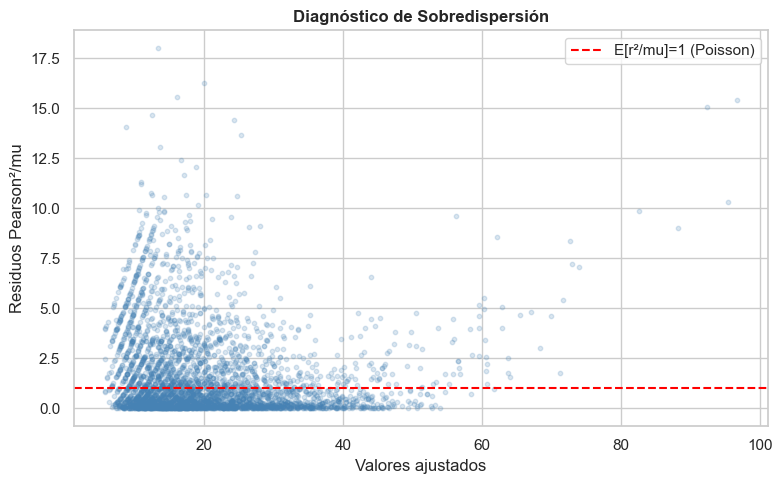

Media residuos Pearson²/mu: 1.6074 (>>1 → sobredispersión)


In [46]:
mu_p=pois_fin.predict(); resid2=(y_cnt-mu_p)**2/mu_p
plt.figure(figsize=(8,5))
plt.scatter(mu_p,resid2,alpha=0.2,s=10,color='steelblue')
plt.axhline(1,color='red',ls='--',label='E[r²/mu]=1 (Poisson)')
plt.xlabel('Valores ajustados'); plt.ylabel('Residuos Pearson²/mu')
plt.title('Diagnóstico de Sobredispersión',fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Media residuos Pearson²/mu: {resid2.mean():.4f} (>>1 → sobredispersión)')

**Conclusión:** los tres métodos convergen. Existe sobredispersión significativa. El Poisson subestima errores estándar. La Binomial Negativa es necesaria.

---
## Pregunta 8 — Modelo Binomial Negativa (NB2)

$$E[Y_i|X_i]=\mu_i \qquad \text{Var}[Y_i]=\mu_i+\alpha\,\mu_i^2$$

**Estrategia:** se intenta primero con todos los predictores. Si aparecen NaN en errores estándar (Hessiana casi singular), se usa el subconjunto `pois_vars`.

In [47]:
print('── Intento con todos los predictores ──')
nb_all    = sm.NegativeBinomial(y_cnt,sm.add_constant(X_cnt)).fit(disp=0,maxiter=500)
n_nan_all = int(nb_all.pvalues.isna().sum())
print(f'NaN en p-values: {n_nan_all} de {len(nb_all.pvalues)}')
print(f'Alpha estimado:  {nb_all.params["alpha"]:.4f}')

if n_nan_all==0:
    print('→ Convergencia OK con todos los predictores.')
    nb_fin=nb_all; nb_vars=feature_cols.copy()
else:
    print(f'→ {n_nan_all} NaN: Hessiana casi singular. Usando pois_vars.\n')
    nb_fin=sm.NegativeBinomial(y_cnt,sm.add_constant(X_cnt[pois_vars])).fit(disp=0,maxiter=500)
    nb_vars=list(pois_vars)
    if int(nb_fin.pvalues.isna().sum())>0:
        print('  Reintentando con bfgs...')
        nb_fin=sm.NegativeBinomial(y_cnt,sm.add_constant(X_cnt[pois_vars])).fit(method='bfgs',maxiter=1000,disp=0)

print('\n Binomial Negativa — Modelo Final')
print(nb_fin.summary2().tables[1].round(4))
print(f'\nLog-Lik={nb_fin.llf:.4f} | AIC={nb_fin.aic:.2f} | BIC={nb_fin.bic:.2f}')
print(f'Alpha={nb_fin.params["alpha"]:.4f} | NaN={int(nb_fin.pvalues.isna().sum())}')

── Intento con todos los predictores ──
NaN en p-values: 24 de 24
Alpha estimado:  1.0513
→ 24 NaN: Hessiana casi singular. Usando pois_vars.


 Binomial Negativa — Modelo Final
                      Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const                1.9614    0.0244  80.4516 0.0000  1.9136  2.0092
upcoming_deadline   -0.0293    0.0109  -2.6885 0.0072 -0.0507 -0.0079
mental_health_score  0.0057    0.0022   2.5774 0.0100  0.0014  0.0100
focus_index          0.0146    0.0008  17.9988 0.0000  0.0130  0.0161
burnout_level       -0.0094    0.0004 -22.7514 0.0000 -0.0102 -0.0086
productivity_score   0.0224    0.0005  41.9727 0.0000  0.0213  0.0234
alpha                0.0284    0.0021  13.4407 0.0000  0.0242  0.0325

Log-Lik=-11451.4984 | AIC=22917.00 | BIC=22960.38
Alpha=0.0284 | NaN=0


In [48]:
print('IRR — Binomial Negativa')
print(irr_table(nb_fin).round(4))

IRR — Binomial Negativa
                       IRR  IC 2.5%  IC 97.5%  p-value
upcoming_deadline   0.9711   0.9506    0.9921   0.0072
mental_health_score 1.0057   1.0014    1.0100   0.0100
focus_index         1.0147   1.0131    1.0163   0.0000
burnout_level       0.9906   0.9898    0.9914   0.0000
productivity_score  1.0226   1.0216    1.0237   0.0000


### Interpretación del Modelo Binomial Negativa

Los **IRR** tienen la misma interpretación que en Poisson, pero con errores estándar **correctamente ajustados por sobredispersión**: los p-values son confiables. El parámetro $\hat{\alpha}$ cuantifica la heterogeneidad no observada entre estudiantes no capturada por los regresores.

In [49]:
irr_n=irr_table(nb_fin)
me_n =marginal_effect_cnt(nb_fin,X_cnt[nb_vars])
mu_nb=nb_fin.predict().mean()
alpha=nb_fin.params['alpha']

print('INTERPRETACIÓN COMPLETA — BINOMIAL NEGATIVA')

print(f'Nota media predicha: {mu_nb:.2f} pts')
print(f'Alpha (dispersión):  {alpha:.4f}')
print(f'  Var(Y)=mu+{alpha:.4f}·mu²: heterogeneidad no observada entre estudiantes.\n')

for v in nb_vars:
    if v not in irr_n.index: continue
    irr=irr_n.loc[v,'IRR']; p=irr_n.loc[v,'p-value']
    lo=irr_n.loc[v,'IC 2.5%']; hi=irr_n.loc[v,'IC 97.5%']
    me=me_n.get(v,np.nan); pct=(irr-1)*100
    dir_='aumenta' if irr>1 else 'reduce'
    print(f'  ▸ {v}')
    print(f'    IRR={irr:.4f} {stars(p)} | IC95%:[{lo:.4f},{hi:.4f}] | p={p:.4f}')
    print(f'    EM={me:+.4f} pts')
    print(f'    — IRR: 1 unidad adicional en "{v}" {dir_} la nota esperada')
    print(f'      en {abs(pct):.2f}%, manteniendo constantes las demás variables.')
    print(f'    — En niveles: {me:+.4f} pts sobre la nota media de {mu_nb:.2f}.')
    print(f'    ({sig_txt(p)}.)')
    print()

INTERPRETACIÓN COMPLETA — BINOMIAL NEGATIVA
Nota media predicha: 20.67 pts
Alpha (dispersión):  0.0284
  Var(Y)=mu+0.0284·mu²: heterogeneidad no observada entre estudiantes.

  ▸ upcoming_deadline
    IRR=0.9711 *** | IC95%:[0.9506,0.9921] | p=0.0072
    EM=-0.6061 pts
    — IRR: 1 unidad adicional en "upcoming_deadline" reduce la nota esperada
      en 2.89%, manteniendo constantes las demás variables.
    — En niveles: -0.6061 pts sobre la nota media de 20.67.
    (estadísticamente significativo al 1%.)

  ▸ mental_health_score
    IRR=1.0057 *** | IC95%:[1.0014,1.0100] | p=0.0100
    EM=+0.1171 pts
    — IRR: 1 unidad adicional en "mental_health_score" aumenta la nota esperada
      en 0.57%, manteniendo constantes las demás variables.
    — En niveles: +0.1171 pts sobre la nota media de 20.67.
    (estadísticamente significativo al 1%.)

  ▸ focus_index
    IRR=1.0147 *** | IC95%:[1.0131,1.0163] | p=0.0000
    EM=+0.3008 pts
    — IRR: 1 unidad adicional en "focus_index" aumenta la

---
## Pregunta 9 — Comparación Poisson vs Binomial Negativa

### 9.A  Test de Razón de Verosimilitud (LRT)

Contrasta $H_0:\alpha=0$ vs $H_1:\alpha>0$. Test de frontera: p-value dividido por 2. Ambos modelos usan el mismo conjunto de variables.

In [50]:
pois_lrt=sm.Poisson(y_cnt,sm.add_constant(X_cnt[nb_vars])).fit(disp=0,maxiter=300)
nb_lrt  =sm.NegativeBinomial(y_cnt,sm.add_constant(X_cnt[nb_vars])).fit(disp=0,maxiter=500)

lrt_stat=-2*(pois_lrt.llf-nb_lrt.llf)
p_lr    =stats.chi2.sf(lrt_stat,df=1)/2

print('LRT: Poisson vs Binomial Negativa')
print(f'  Variables: {nb_vars}')
print(f'  LL Poisson: {pois_lrt.llf:.4f} | LL NB: {nb_lrt.llf:.4f}')
print(f'  LRT stat:   {lrt_stat:.4f} | p-value: {p_lr:.8f}')
if p_lr<0.05: print('  → RECHAZA H0: NB supera significativamente al Poisson')

LRT: Poisson vs Binomial Negativa
  Variables: ['upcoming_deadline', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score']
  LL Poisson: -11632.4080 | LL NB: -11451.4984
  LRT stat:   361.8191 | p-value: 0.00000000
  → RECHAZA H0: NB supera significativamente al Poisson


In [51]:
print(f'{"Modelo":<25} {"Log-Lik":>12} {"AIC":>10} {"BIC":>10} {"Alpha":>10}')
print('-'*70)
print(f'{"Poisson (final)":<25} {pois_fin.llf:>12.4f} {pois_fin.aic:>10.2f} {pois_fin.bic:>10.2f} {"N/A":>10}')
print(f'{"Binomial Neg. (final)":<25} {nb_fin.llf:>12.4f} {nb_fin.aic:>10.2f} {nb_fin.bic:>10.2f} {nb_fin.params["alpha"]:>10.4f}')
print('\nAmbos modelos usan el mismo conjunto de variables.')

Modelo                         Log-Lik        AIC        BIC      Alpha
----------------------------------------------------------------------
Poisson (final)            -11632.4080   23276.82   23314.00        N/A
Binomial Neg. (final)      -11451.4984   22917.00   22960.38     0.0284

Ambos modelos usan el mismo conjunto de variables.


### 9.B  Variables Robustas

In [52]:
models_cnt={'Poisson':(pois_fin,pois_vars),'NegBin':(nb_fin,nb_vars)}
rob_cnt   =robustness_table(models_cnt,set(pois_vars)|set(nb_vars))
print('Tabla de Robustez — Modelos de Conteo')
print('(*** p<0.01  ** p<0.05  * p<0.10  ns=no sig.  —=no incluida)')
print(rob_cnt.to_string()); print()
robust_vars_cnt=[v for v in rob_cnt.index
                 if all(rob_cnt.loc[v,c] not in ['—','ns'] for c in rob_cnt.columns)]
print(f'Variables robustas: {robust_vars_cnt}')

Tabla de Robustez — Modelos de Conteo
(*** p<0.01  ** p<0.05  * p<0.10  ns=no sig.  —=no incluida)
                    Poisson NegBin
Variable                          
burnout_level           ***    ***
focus_index             ***    ***
mental_health_score     ***    ***
productivity_score      ***    ***
upcoming_deadline       ***    ***

Variables robustas: ['burnout_level', 'focus_index', 'mental_health_score', 'productivity_score', 'upcoming_deadline']


In [53]:
irr_pf=irr_table(pois_fin); irr_nf=irr_table(nb_fin)
common=sorted(set(pois_vars)&set(nb_vars))
print(f'{"Variable":<25} {"IRR Poisson":>13} {"p(Pois.)":>10} {"IRR NB":>10} {"p(NB)":>10}')
print('-'*72)
for v in common:
    ip=irr_pf.loc[v,'IRR'] if v in irr_pf.index else np.nan
    nb_=irr_nf.loc[v,'IRR'] if v in irr_nf.index else np.nan
    pp=irr_pf.loc[v,'p-value'] if v in irr_pf.index else np.nan
    pn=irr_nf.loc[v,'p-value'] if v in irr_nf.index else np.nan
    print(f'  {v:<23} {ip:>13.4f} {pp:>10.4f} {nb_:>10.4f} {pn:>10.4f}')

Variable                    IRR Poisson   p(Pois.)     IRR NB      p(NB)
------------------------------------------------------------------------
  burnout_level                  0.9913     0.0000     0.9906     0.0000
  focus_index                    1.0136     0.0000     1.0147     0.0000
  mental_health_score            1.0071     0.0000     1.0057     0.0100
  productivity_score             1.0214     0.0000     1.0226     0.0000
  upcoming_deadline              0.9737     0.0017     0.9711     0.0072


### 9.C  Discusión

**1. Coeficientes similares, errores estándar distintos:** La sobredispersión no sesga los coeficientes del Poisson (sigue siendo consistente), pero subestima sus errores estándar en un factor $\approx\sqrt{1+\alpha\bar{\mu}}$. Esto infla los t-estadísticos y produce p-values artificialmente pequeños, declarando significativos efectos que no lo son al nivel de confianza correcto.

**2. Origen de la sobredispersión:** Heterogeneidad no observada entre estudiantes — diferencias en motivación, contexto familiar, estado de salud el día del examen, etc. — que genera variación adicional más allá de lo que capturan los regresores.

**3. Modelo más adecuado:** La **Binomial Negativa** es el modelo correcto: (a) ratio Var/Media >> 1, (b) Cameron-Trivedi rechaza $H_0$ con p ≈ 0, (c) LRT rechaza Poisson con p ≈ 0, (d) NB tiene AIC y BIC menores.

**4. Comparabilidad:** Ambos modelos usan el mismo conjunto de variables, garantizando que la única diferencia sea el supuesto distribucional.

**5. Variables robustas:** las listadas en 9.B tienen efectos genuinos sobre la nota del examen, robustos al supuesto distribucional elegido.